In [1]:
import os
print("Working directory:", os.getcwd())
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV'))

Working directory: /shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw/notebooks
Conda environment: wnw


In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

from scipy.stats import mannwhitneyu
from collections import Counter
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests, fdrcorrection

# custom imports
import utils

## **1. Prepping the data**

### Get sample metadata

In [3]:
basedir = '/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/'
metadata = pd.read_table(os.path.join(basedir,'nw_metadata.tsv'))

# Filter metadata
adults_metadata = metadata[metadata['age'] != pd.NA]
adults_metadata = adults_metadata[adults_metadata['age'] != np.nan]
adults_metadata = adults_metadata[adults_metadata['age'].notna()]
adults_metadata = adults_metadata[adults_metadata['age'] != '1.083.333.333']
adults_metadata['age'] = adults_metadata['age'].astype(float)
adults_metadata = adults_metadata[adults_metadata['age'] > 16]
adults_metadata = adults_metadata[adults_metadata['study_name'] != 'HanniganGD_2017']
adults_metadata.index = adults_metadata['sample_id']

# Isolate metadata from ancient samples
# and append metadata from adults
ancient_metadata = metadata[metadata['non_westernized'] == 'ancient']
ancient_metadata.index = ancient_metadata['sample_id']
ancient_adult_metadata = pd.concat([ancient_metadata, adults_metadata])

# Save filtered metadata (for reproducibility)
ancient_adult_metadata.to_csv("../data/ancient_adults_metadata_filtered.tsv", sep="\t")

### Get SGB abundances

In [4]:
# Read file with SGB abundances
abundances = pd.read_table(os.path.join(basedir,'nw_profiles.tsv'), index_col=[0])

# Only keep SGBs with strain-level annotation
keep = list()
for x in abundances.index.tolist():
    keep.append('t__' in x)
sgb_abundances = abundances.loc[keep]

# Simplify annotation for SGBs
sgb_abundances.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in sgb_abundances.index.tolist()]

# Subset abundance df with selected samples
adults_abundances = sgb_abundances[adults_metadata.index]
ancient_adult_abundances = sgb_abundances[ancient_adult_metadata.index]

# Remove SGBs that are totally absent in remaining samples
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())

# And similarly, remove samples that don't have any of the remaining SGBs in them
adults_abundances = adults_abundances.transpose()
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())

# Repeat for total dataset
ancient_adult_abundances = ancient_adult_abundances.drop(ancient_adult_abundances.loc[ancient_adult_abundances.sum(axis=1) == 0].index.tolist())
ancient_adult_abundances = ancient_adult_abundances.transpose()
ancient_adult_abundances = ancient_adult_abundances.drop(ancient_adult_abundances.loc[ancient_adult_abundances.sum(axis=1) == 0].index.tolist())

alt_ids = ["__".join(re.match(r"(.+?) \((.+)\)",i).groups()[::-1]).replace(" ", "_") for i in ancient_adult_abundances]
ancient_adult_abundances.columns = alt_ids

print('Number of SGBs after filtering:', ancient_adult_abundances.shape[1])

Number of SGBs after filtering: 4438


Calculate SGB prevalence across W and NW samples.

In [5]:
ancient_adult_prevs = ancient_adult_abundances.T.astype(bool).astype(int)

nw = ancient_adult_metadata[ancient_adult_metadata.non_westernized == "yes"].index.tolist()
w = ancient_adult_metadata[ancient_adult_metadata.non_westernized == "no"].index.tolist()

nw = list(set(nw).intersection(ancient_adult_prevs.columns))
w = list(set(w).intersection(ancient_adult_prevs.columns))

prevs_sum = pd.concat([
    ancient_adult_prevs[nw].sum(axis=1),
    ancient_adult_prevs[w].sum(axis=1)
    ], axis=1)

prevs_sum.columns = ["present_nw","present_w"]
prevs_sum

,present_nw,present_w
SGB1626__Prevotella_copri_clade_A,1009,2499
SGB4290__Ruminococcus_sp_NSJ_71,595,1309
SGB5117__Coprococcus_eutactus,652,2486
SGB4260__GGB3226_SGB4260,127,97
SGB15234__Ruminococcaceae_unclassified_SGB15234,795,2977
...,...,...
SGB28493__Arcobacter_trophiarum,1,0
SGB89540__Aquamicrobium_lusatiense,1,0
SGB8530__Proteiniborus_ethanoligenes,1,0
SGB87720__Propioniciclava_sp_MC1595,1,0


In [6]:
method = "abundance"

# Potential confounding variables
# to take into account in model
confounders = [
    'study_name',
    'age',
    'gender',
    'sequencing_platform',
    'DNA_extraction_kit',
    'number_reads'
    ]

# Outcome variable
target_col = ['non_westernized']

colselect = target_col + confounders

if method == "prevalence":
    counts_table = ancient_adult_prevs.T.copy()
elif method == "abundance":
    counts_table = ancient_adult_abundances.copy()
    
print(f"{method} table:", counts_table.shape[0])
print("metadata table:", ancient_adult_metadata.shape[0])

# Parsing
meta_analysis = ancient_adult_metadata[colselect].merge(counts_table, left_index=True, right_index=True)
# meta_analysis = meta_analysis[meta_analysis.study_name.isin(valid_studies)] # remove mixed studies
meta_analysis = meta_analysis[meta_analysis.non_westernized.isin(["yes","no"])] # remove ancient samples
meta_analysis["DNA_extraction_kit"] = meta_analysis["DNA_extraction_kit"].fillna("unknown")
meta_analysis["gender"] = meta_analysis["gender"].fillna("unknown")

# Save full meta analysis table
meta_analysis.to_csv("../data/wnw_abundance_meta.tsv",sep="\t")
meta_analysis.head()

abundance table: 6888
metadata table: 6892


,non_westernized,study_name,age,gender,sequencing_platform,DNA_extraction_kit,number_reads,SGB1626__Prevotella_copri_clade_A,SGB4290__Ruminococcus_sp_NSJ_71,SGB5117__Coprococcus_eutactus,...,SGB32233__Aquamicrobium_defluvii,SGB64172__Jeotgalibaca_porci,SGB10725__Paracoccus_solventivorans,SGB32666__Paracandidimonas_soli,SGB10726__Paracoccus_alkenifer,SGB28493__Arcobacter_trophiarum,SGB89540__Aquamicrobium_lusatiense,SGB8530__Proteiniborus_ethanoligenes,SGB87720__Propioniciclava_sp_MC1595,SGB11414__Bosea_sp_WAO
O2_UC49_0,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,60584637.0,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC49_2,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,56508214.0,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_0,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,65105855.0,0.99226,7.81511,0.05737,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_2,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,53260679.0,0.00000,5.32192,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC51_0,no,NielsenHB_2014,32.0,female,IlluminaHiSeq,unknown,57486896.0,0.00000,0.00000,4.03200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **2. Enrichment analysis**

### 2.1. Food-associated SGB enrichment

Are NW/W gut microbiomes enriched for certain food-related SGBs? To study this we will have a look at food metagenomics studies in [curatedFoodMetagenomicData (cFMD)](https://github.com/SegataLab/cFMD).

#### Some pre-filtering first
To select studies (from cFMD entries) for which the Jan21 MetaPhlan4 profiles are available.

In [7]:
food_meta = pd.read_table("../data/cFMD_metadata.tsv")
data_dir = "/shares/CIBIO-Storage/CM/scratch/data/meta/"

datasets = food_meta.dataset_name.unique()
check = {}

# For each study, check if Jan21 MetaPhlan4 profiles are present
for dataset in datasets:
    dataset_root = os.path.join(data_dir, dataset)
    # Ensure the dataset directory exists
    if not os.path.exists(dataset_root):
        check[dataset] = (False, None)
        continue
    try:
        subdirs = os.listdir(dataset_root)
        metaphlan_dirs = [
            d for d in subdirs
            if "metaphlan-4" in d and "Jan21" in d
        ]
        if metaphlan_dirs:
            # Take the first match (or all if you want)
            matched_dir = metaphlan_dirs[0]
            check[dataset] = (True, matched_dir)
        else:
            check[dataset] = (False, None)
    except Exception as e:
        check[dataset] = (False, None)

# Only keep studies that have the Jan21 MetaPhlan4 profiles
check_df = pd.DataFrame(check).T
check_df.columns = ["has_jan21_profiles", "sample_dir"]
check_df = check_df[check_df.has_jan21_profiles]
selected_studies = check_df.index
print(f"Datasets with Jan21 profiles: {len(selected_studies)}/{len(datasets)}")
dataset2sampledir = dict(zip(check_df.index,check_df.sample_dir))
food_meta = food_meta[food_meta.dataset_name.isin(selected_studies)]

# Assign path to Jan21 MetaPhlan4 profiles
profile_paths = []
for i in food_meta.index:
    dataset = food_meta.loc[i].dataset_name
    sample_root = dataset2sampledir[dataset]
    sample_id = food_meta.loc[i].sample_id
    profile_id = f"{sample_id}_profile.tsv"
    profile_paths.append(os.path.join(data_dir,dataset,sample_root,sample_id,profile_id))

food_meta["profile_path"] = profile_paths

# Filter out food categories for which we have < 20 samples
cat_count = food_meta["category"].value_counts()
cats_over_20 = list(cat_count[cat_count>20].index)
food_meta = food_meta[food_meta["category"].isin(cats_over_20)]

food_meta["unique_sample_id"] = food_meta.dataset_name + "_" + food_meta.sample_id
food_meta = food_meta.set_index("unique_sample_id")

Datasets with Jan21 profiles: 59/85


#### Create an SGB-food index
Where every SGB gets assigned to a certain food, if that SGB is found in a sample from that food.

In [8]:
profile_cols = ["clade_name", "NCBI_tax_id", "relative_abundance", "additional_species"]

# Dictionary of SGBs (keys) and food types/categories (values)
# e.g. {'Staphylococcus equorum (SGB7843)': ['meat','meat','meat','dairy']}
sgb_food_index = {}

for n in food_meta.index:
    print(n)
    example_profile = food_meta.loc[n].profile_path
    food_type = food_meta.loc[n]["category"]
    try:
        df = pd.read_csv(
            example_profile,
            sep="\t",
            comment="#",
            header=None
        )
        df.columns = profile_cols
        df = df.set_index("clade_name")
        keep = list()
        for x in df.index.tolist():
            keep.append('t__' in x)
        df = df[keep]
        df.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in df.index.tolist()]
        # For every SGB in this sample, assign that sample's food category to that SGB
        for sgb in df.index:
            if sgb not in sgb_food_index:
                sgb_food_index[sgb] = [food_type]
            else:
                sgb_food_index[sgb].append(food_type)
    except pd.errors.EmptyDataError:
        pass

AlvarezOrdonezA_xxxx_C01-16
AlvarezOrdonezA_xxxx_C01-17
AlvarezOrdonezA_xxxx_C01-18
AlvarezOrdonezA_xxxx_C01-19
AlvarezOrdonezA_xxxx_C02-16
AlvarezOrdonezA_xxxx_C02-17
AlvarezOrdonezA_xxxx_C02-18
AlvarezOrdonezA_xxxx_C02-19
AlvarezOrdonezA_xxxx_C03-16
AlvarezOrdonezA_xxxx_C03-17
AlvarezOrdonezA_xxxx_C03-18
AlvarezOrdonezA_xxxx_C03-19
AlvarezOrdonezA_xxxx_C04-16
AlvarezOrdonezA_xxxx_C04-17
AlvarezOrdonezA_xxxx_C04-18
AlvarezOrdonezA_xxxx_C04-19
AlvarezOrdonezA_xxxx_C05-16
AlvarezOrdonezA_xxxx_C05-17
AlvarezOrdonezA_xxxx_C05-18
AlvarezOrdonezA_xxxx_C05-19
AlvarezOrdonezA_xxxx_C06-16
AlvarezOrdonezA_xxxx_C06-17
AlvarezOrdonezA_xxxx_C06-18
AlvarezOrdonezA_xxxx_C06-19
AlvarezOrdonezA_xxxx_C07-16
AlvarezOrdonezA_xxxx_C07-17
AlvarezOrdonezA_xxxx_C07-18
AlvarezOrdonezA_xxxx_C07-19
AlvarezOrdonezA_xxxx_C08-16
AlvarezOrdonezA_xxxx_C08-17
AlvarezOrdonezA_xxxx_C08-18
AlvarezOrdonezA_xxxx_C08-19
AlvarezOrdonezA_xxxx_F01-16
AlvarezOrdonezA_xxxx_F01-17
AlvarezOrdonezA_xxxx_F01-18
AlvarezOrdonezA_xxxx

#### **Creating food-specific signatures**
First, we will create a signature set of SGBs that are associated with a specific food category.

Start by creating an abundance table (samples x SGBs).

In [9]:
food_ab = []
for n in food_meta.index:
    example_profile = food_meta.loc[n].profile_path
    food_id, food_type = food_meta.loc[n][["type","category"]]
    dataset, sample = food_meta.loc[n][["dataset_name","sample_id"]] 	
    try:
        df = pd.read_csv(
            example_profile,
            sep="\t",
            comment="#",
            header=None
        )
        df.columns = profile_cols
        df = df.set_index("clade_name")
        keep = list()
        for x in df.index.tolist():
            keep.append('t__' in x)
        df = df[keep]
        df.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in df.index.tolist()]
        df['sample_id'] = f'{dataset}_{sample}'
        df['food_id'] = food_id
        df['food_category'] = food_type
        df = df.reset_index().rename(columns={'index':'sgb_id'})
        cols = ['sample_id', 'food_id', 'food_category', 'sgb_id', 'relative_abundance']
        food_ab.append(df[cols])
    except pd.errors.EmptyDataError:
        pass

food_ab = pd.concat(food_ab)

food_ab_wide = food_ab.pivot_table(
    index='sample_id',
    columns='sgb_id',
    values='relative_abundance',
    fill_value=0
)

print(food_ab_wide.shape)

food_ab_wide = food_ab_wide.loc[food_ab_wide.index.intersection(food_meta.index)]

# Filter on prevalence of SGB per food category
# Only keep SGB-food combinations with prev > 0.1
presence = (food_ab_wide > 0).astype(int)
presence["food_category"] = food_meta.loc[presence.index, "category"]
prevalence = presence.groupby("food_category").mean().T
prevalence_long = prevalence.stack().reset_index()
prevalence_long.columns = ["sgb_id","food_category","prevalence_in_cat"]

food_ab = food_ab.merge(prevalence_long,on=["sgb_id","food_category"])
food_ab = food_ab[food_ab.prevalence_in_cat > 0.1]

food_ab_wide = food_ab.pivot_table(
    index='sample_id',
    columns='sgb_id',
    values='relative_abundance',
    fill_value=0
)

print(food_ab_wide.shape)

(2430, 3165)
(2392, 655)


In [12]:
food_ab.head()

,sample_id,food_id,food_category,sgb_id,relative_abundance,prevalence_in_cat
0,AlvarezOrdonezA_xxxx_C01-18,meat,fermented_meat,Staphylococcus equorum (SGB7843),74.80553,0.828125
1,AlvarezOrdonezA_xxxx_C02-18,meat,fermented_meat,Staphylococcus equorum (SGB7843),0.87346,0.828125
2,AlvarezOrdonezA_xxxx_C02-19,meat,fermented_meat,Staphylococcus equorum (SGB7843),13.12213,0.828125
3,AlvarezOrdonezA_xxxx_C04-18,meat,fermented_meat,Staphylococcus equorum (SGB7843),13.41005,0.828125
4,AlvarezOrdonezA_xxxx_C05-18,meat,fermented_meat,Staphylococcus equorum (SGB7843),28.60762,0.828125


Get matching meta data and perform CLR transformation of the abundances.

In [11]:
def clr_transform(df, pseudocount=1e-6):
    """
    Apply Centered Log-Ratio (CLR) transformation to a DataFrame of relative abundances.

    Parameters:
        df (pd.DataFrame): abundance table (samples × features)
        pseudocount (float): small value added to avoid log(0)

    Returns:
        pd.DataFrame: CLR-transformed abundance table
    """
    # Add pseudocount to avoid zeros
    df_pseudo = df + pseudocount

    # Log transform
    log_df = np.log(df_pseudo)

    # CLR: subtract geometric mean of each sample
    clr_df = log_df.sub(log_df.mean(axis=1), axis=0)

    return clr_df

food_meta_wide = food_ab[['sample_id','food_id','food_category']].drop_duplicates().set_index('sample_id')
clr_food_ab = clr_transform(food_ab_wide)

/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


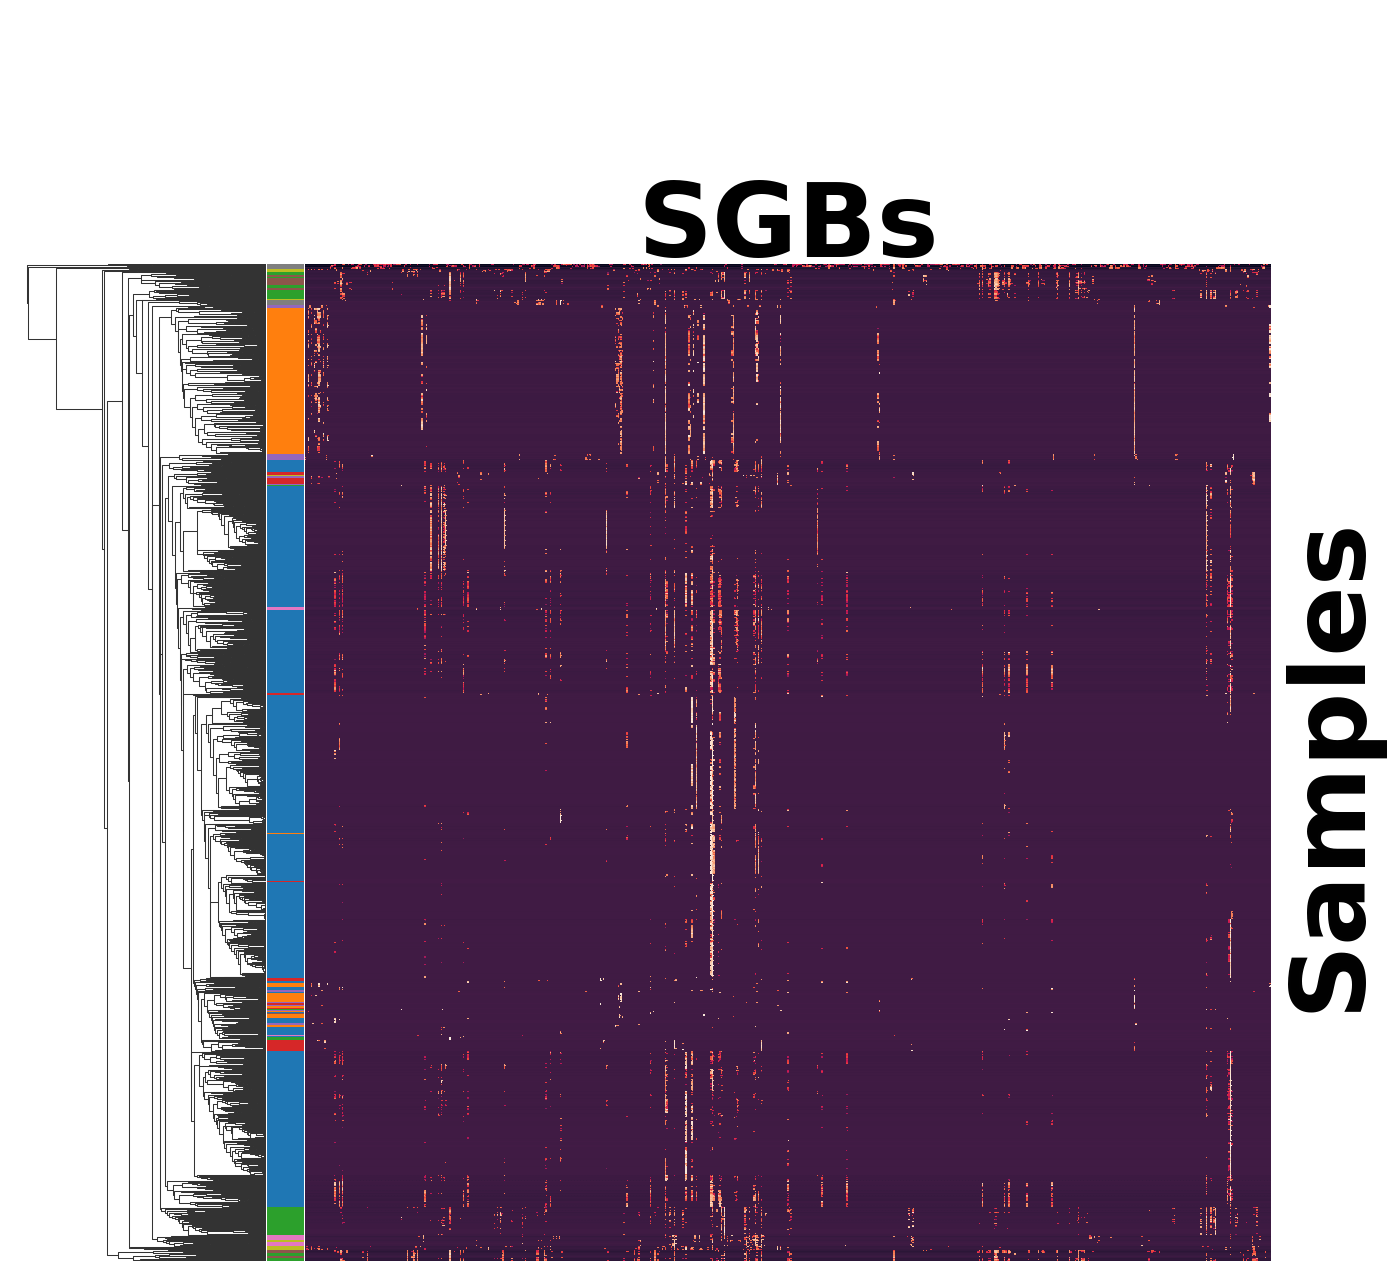

In [13]:
tab10 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
        '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

mapping = {
    "dairy": tab10[0],
    "fermented_beverages": tab10[1],
    "fermented_meat": tab10[2],
    "fermented_grains": tab10[3],
    "alcohol": tab10[4],
    "meat": tab10[5],
    "fermented_fruits_and_vegetables": tab10[6],
    "fruits_and_vegetables": tab10[7],
    "fermented_tubers_and_roots": tab10[8],
}

sample2color = dict(food_meta["category"].map(mapping))

row_colors = clr_food_ab.index.map(sample2color)

sns.reset_defaults()

plt.rcParams['font.family'] = 'sans-serif'   # could be 'serif', 'monospace', etc.
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']  # fallback list
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['font.size'] = 15           # default text size
plt.rcParams['axes.labelsize'] = 50      # x/y label size
plt.rcParams['axes.titlesize'] = 30      # title size
plt.rcParams['xtick.labelsize'] = 0     # tick label size
plt.rcParams['ytick.labelsize'] = 0
# plt.rcParams['legend.fontsize'] = 15
# # plt.rcParams['figure.titlesize'] = 18    # suptitle size
plt.rcParams['axes.linewidth'] = 2     # axis line thickness
plt.rcParams['lines.linewidth'] = 2      # default line thickness
plt.rcParams['figure.dpi'] = 150

g = sns.clustermap(clr_food_ab, row_colors=row_colors, col_cluster=False)
g.cax.set_visible(False)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_xlabel("SGBs")
g.ax_heatmap.set_ylabel("Samples")
g.ax_heatmap.xaxis.set_label_position('top')
# plt.savefig("../fig/sample_sgb_matrix_example.png",format="png",dpi=500,bbox_inches="tight")
plt.show()


Fix the SGB names (to match format of the meta analysis table).

In [14]:
old2newidx = {i:"__".join(re.match(r"(.+?) \((.+)\)",i).groups()[::-1]).replace(" ", "_") for i in food_ab.sgb_id.unique()}

Perform statistical test to determine whether SGB is more abundant in one food category vs rest.

In [15]:
sigs = []

for sgb in clr_food_ab.columns:
    values = clr_food_ab[sgb]
    # Isolate 1 food group, test vs others
    for category in food_meta_wide['food_category'].unique():
        group = values[food_meta_wide['food_category'] == category]
        other = values[food_meta_wide['food_category'] != category]
        
        if len(group) < 10 or len(other) < 10:
            continue  # skip tiny groups

        # MWU
        stat, pval = mannwhitneyu(group, other, alternative='greater')
        mean_diff = group.mean() - other.mean()

        # Save results
        sigs.append({
            'sgb_id': sgb,
            'food_category': category,
            'pval': pval,
            'mean_diff': mean_diff,
            'mean_in_category': group.mean(),
            'mean_out_category': other.mean(),
        })

# Summarize
signatures = pd.DataFrame(sigs)

# Multiple testing correction (BH method)
signatures["qval"] = multipletests(signatures.pval, method="fdr_bh")[1]

In [16]:
# sgb_example = 'Saccharomyces cerevisiae (EUK4932)'
# category = 'alcohol'

# values = clr_food_ab[sgb_example]
# group = values[food_meta_wide['food_category'] == category]
# other = values[food_meta_wide['food_category'] != category]

# group = group.reset_index()
# group["group"] = "alcohol"

# other = other.reset_index()
# other["group"] = "other"

# testing = pd.concat([group, other])

# plt.rcParams['axes.linewidth'] = 2     # axis line thickness
# plt.rcParams['lines.linewidth'] = 6  

# fig, ax = plt.subplots(figsize=(5,5))
# sns.boxplot(data = testing, x = "group", y = sgb_example, ax=ax)
# sns.stripplot(data = testing, x = "group", y = sgb_example, ax=ax, color="black", size=15, alpha=0.5)
# ax.set_title("S. cerevisiae")
# ax.set_ylabel("rel. abundance")
# plt.show()

# fig.savefig("../fig/food_signature_example.png", format="png", dpi=500, bbox_inches="tight")

In [17]:
# Get set of signature SGBs per food category
food_sig_sets = signatures[signatures["qval"]<.05].groupby("food_category")['sgb_id'].apply(list).to_dict()

allsigsgbs = []
for i in food_sig_sets.values():
    allsigsgbs += i
allsigsgbsunique = set(allsigsgbs)

In [18]:
# Get set of signature SGBs per food category
food_sig_sets = signatures[signatures["qval"]<.05].groupby("food_category")['sgb_id'].apply(list).to_dict()

# Extract metadata columns
metadata_cols = meta_analysis.columns[:7]

# Select food SGBs that overlap with SGBs in our dataset
food_sgbs = set([old2newidx[i] for i in signatures.sgb_id.unique()])
gut_sgbs = set(meta_analysis.columns[7:])
ovl_sgbs = food_sgbs.intersection(gut_sgbs)
foodsig = [old2newidx[i] for i in allsigsgbsunique]
foodsig_ovl = set(meta_analysis.columns).intersection(foodsig) # Final set of all food SGBs that overlap with W/NW dataset SGBs

In [20]:
signatures_sig = signatures[signatures.qval<.01]
signatures_sig_filtered = signatures_sig[~signatures_sig.food_category.isin(["fermented_tubers_and_roots","fruits_and_vegetables"])]

In [21]:
prev_table = (
    signatures_sig_filtered.assign(present=1)
      .pivot_table(index="sgb_id", columns="food_category", values="present", fill_value=0)
)

# prev_table.index = signatures_sig_filtered.groupby("sgb_id")["sgb_id"].first()

# prev_table.to_csv("sgb_food_prevalence.csv")

sns.clustermap(prev_table, figsize=(20,20))

In [25]:
df_fi = pd.read_table("../data/nw_classifier_feature_importances.tsv")

print(signatures_sig_filtered[signatures_sig_filtered.food_category=="alcohol"].shape)

merged = signatures_sig_filtered[signatures_sig_filtered.food_category=="alcohol"].merge(df_fi, on="sgb_id")
merged

(36, 7)


,sgb_id,food_category,pval,mean_diff,mean_in_category,mean_out_category,qval,fi_rank,mean_fi,std_fi
0,Acetobacter pasteurianus (SGB1196),alcohol,5.175700e-08,3.621670,3.420601,-0.201069,3.029242e-07,2365,9.574345e-06,2.113711e-05
1,Apilactobacillus kunkeei (SGB7157),alcohol,2.717982e-04,2.469946,2.235966,-0.233980,1.211990e-03,2626,7.443678e-06,2.471655e-05
2,Candida tropicalis (EUK5482),alcohol,6.037486e-04,1.585023,1.364613,-0.220410,2.648138e-03,3340,3.476170e-06,1.871975e-05
3,Fructobacillus durionis (SGB7133),alcohol,2.275618e-04,1.597617,1.363637,-0.233980,1.018585e-03,3639,1.806511e-06,7.170860e-06
4,Lactiplantibacillus plantarum (SGB7202),alcohol,1.129042e-05,2.725992,4.627065,1.901073,5.171484e-05,1370,4.021648e-05,1.058746e-04
5,Lactobacillus crispatus (SGB7045),alcohol,2.906758e-04,1.556301,1.361413,-0.194888,1.294792e-03,1342,4.291275e-05,1.031597e-04
6,Lactobacillus gasseri (SGB7038_group),alcohol,2.275618e-04,1.453019,1.219039,-0.233980,1.018585e-03,881,1.172874e-04,1.247118e-04
7,Lactobacillus harbinensis (SGB7136),alcohol,1.751805e-03,0.929869,1.107692,0.177823,7.582150e-03,2024,1.322980e-05,4.850834e-05
8,Lactobacillus mali (SGB7073),alcohol,1.097823e-03,1.504045,1.530856,0.026812,4.783197e-03,2691,6.978766e-06,2.800809e-05
9,Leuconostoc fallax (SGB29566),alcohol,3.689296e-04,1.192253,1.040826,-0.151427,1.632763e-03,2820,6.218691e-06,3.124304e-05


In [26]:
sample_to_lifestyle = dict(zip(adults_metadata.sample_id, adults_metadata.non_westernized))
wnw_ratio = adults_abundances.copy()
wnw_ratio["non_westernized"] = [sample_to_lifestyle[i] for i in adults_abundances.index]

wnw_ratio_abundances = (wnw_ratio.groupby("non_westernized").mean().loc["no"] + 1e-6) / (wnw_ratio.groupby("non_westernized").mean().loc["yes"] + 1e-6)

wnw_ratio = wnw_ratio.astype(bool).astype(int)
wnw_ratio["non_westernized"] = [sample_to_lifestyle[i] for i in adults_abundances.index]

wnw_ratio_prev = wnw_ratio.groupby("non_westernized").sum() + 1
n_w, n_nw = wnw_ratio.non_westernized.value_counts()
wnw_ratio_prev = (wnw_ratio_prev.loc["no"] / n_w) / (wnw_ratio_prev.loc["yes"] / n_nw)
# wnw_ratio_prevalences = 

In [27]:
wnw_ratio_prev = wnw_ratio.groupby("non_westernized").sum() + 1
n_w, n_nw = wnw_ratio.non_westernized.value_counts()
wnw_ratio_prev = (wnw_ratio_prev.loc["no"] / n_w) / (wnw_ratio_prev.loc["yes"] / n_nw)

In [28]:
merged["abundance_ratio_w_nw"] = merged.sgb_id.map(wnw_ratio_abundances.to_dict())
merged["prevalence_ratio_w_nw"] = merged.sgb_id.map(wnw_ratio_prev.to_dict())

#### **Abundance-based model**
Do microbiome profiles from NW individuals have a differential relative abundance for certain food-associated SGBs compared to W individuals?


In [671]:
# CLR transformation
# -- ignore --
# meta_analysis_clr = clr_transform(meta_analysis[list(ovl_sgbs)], pseudocount=1e-6)

In [32]:
# Prep data for modeling
meta_analysis_normalized = meta_analysis[list(ovl_sgbs)] / 100
meta_analysis_foodsgbs = pd.concat([meta_analysis[metadata_cols], meta_analysis_normalized], axis=1)

# Compute cumulative abundance of signature SGBs per food category
final = meta_analysis[metadata_cols].copy()
for food_cat in food_sig_sets.keys():
    foodsig = [old2newidx[i] for i in food_sig_sets[food_cat]]
    foodsig_ovl = list(set(meta_analysis.columns).intersection(foodsig))
    final["sig_"+food_cat] = meta_analysis_foodsgbs[foodsig_ovl].sum(axis=1)

# Make sure columns are encoded correctly
final["non_westernized"] = final.non_westernized.map({"yes":1,"no":0})
final["age"] = final["age"].astype(int)
final["number_reads"] = final["number_reads"].astype(int)
final = final[final.gender.isin(["male","female"])]
final["gender"] = final["gender"].astype("category")
final["sequencing_platform"] = final["sequencing_platform"].astype("category")

final.head()

,non_westernized,study_name,age,gender,sequencing_platform,DNA_extraction_kit,number_reads,sig_alcohol,sig_dairy,sig_fermented_beverages,sig_fermented_fruits_and_vegetables,sig_fermented_grains,sig_fermented_meat,sig_fermented_tubers_and_roots,sig_fruits_and_vegetables,sig_meat
O2_UC49_0,0,NielsenHB_2014,22,female,IlluminaHiSeq,unknown,60584637,0.000000,0.029045,0.000000,0.000000,0.029118,0.000072,0.000000,0.0,0.0
O2_UC49_2,0,NielsenHB_2014,22,female,IlluminaHiSeq,unknown,56508214,0.000000,0.109104,0.000193,0.009515,0.109104,0.000000,0.000000,0.0,0.0
O2_UC50_0,0,NielsenHB_2014,24,male,IlluminaHiSeq,unknown,65105855,0.000000,0.111018,0.000000,0.000030,0.110855,0.000000,0.000000,0.0,0.0
O2_UC50_2,0,NielsenHB_2014,24,male,IlluminaHiSeq,unknown,53260679,0.000000,0.098544,0.000267,0.005614,0.098544,0.000000,0.000000,0.0,0.0
O2_UC51_0,0,NielsenHB_2014,32,female,IlluminaHiSeq,unknown,57486896,0.000022,0.098806,0.000000,0.003050,0.097059,0.000000,0.000022,0.0,0.0


In [33]:
final = final[final.gender.isin(["male","female"])]
final = final.drop(columns=["sig_fruits_and_vegetables"])

In [34]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = final[["non_westernized", "age", "gender", "number_reads", "sequencing_platform"]]
X = pd.get_dummies(X, drop_first=True)  # ensure categorical vars are coded properly
vif_data = pd.DataFrame()
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data["feature"] = X.columns
print(vif_data)


        VIF                              feature
0  1.247100                      non_westernized
1  3.126584                                  age
2  0.334509                         number_reads
3  1.629472                          gender_male
4  1.036167  sequencing_platform_IlluminaNextSeq
5  1.287770  sequencing_platform_IlluminaNovaSeq


**Modeling**\
Use linear mixed effects model with:
- Random effect (RE): study
- Fixed effects (FE): age, gender, number reads, sequencing platform  

In [35]:
signatures = [c for c in final.columns if c.startswith("sig_")]
model_results = []

for sig in signatures:
    formula = f"{sig} ~ non_westernized + age + gender + number_reads + sequencing_platform"
    md = smf.mixedlm(formula, final, groups=final["study_name"]).fit()
    cat_res = pd.concat([md.params, md.bse, md.pvalues], axis=1)
    cat_res = cat_res.reset_index()
    cat_res.columns = ["parameter","coef","stderr","pval"]
    cat_res["ci_upper"] = cat_res["coef"].astype(float) + cat_res["stderr"].astype(float)
    cat_res["ci_lower"] = cat_res["coef"].astype(float) - cat_res["stderr"].astype(float)
    cat_res["food_category"] = sig[4:]
    model_results.append(cat_res)

model_results_df = pd.concat(model_results)

# Overlap with these SGBs is too small to draw meaningful conclusions
# --> remove
model_results_df = model_results_df[model_results_df.food_category != "fruits_and_vegetables"]
# model_results_df = model_results_df[model_results_df.food_category != "fermented_tubers_and_roots"]
model_results_df["food_category"] = model_results_df.food_category.apply(lambda x: " ".join(x.split("_")))

/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: 

In [69]:
model_results_df.to_csv(
    "../data/food_abundance_lmem_results.tsv", 
    sep="\t", 
    index=False
    )

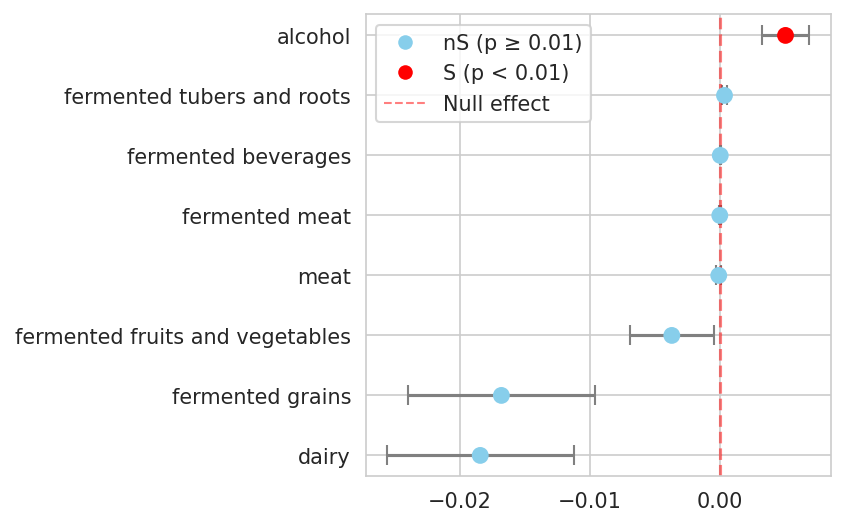

In [65]:
utils.plot_coefficients(
    model_results_df[model_results_df["parameter"] == "non_westernized"],
    title = "",
    ylab="",
    xlab="",
    # outfile = "../fig/food_mlm_abundance"
)

In [81]:
model_results_df[model_results_df["parameter"] == "non_westernized"]

,parameter,coef,stderr,pval,ci_upper,ci_lower,food_category
4,non_westernized,0.005067,0.001842,0.005944,0.006909,0.003225,alcohol
4,non_westernized,-0.018415,0.007195,0.010492,-0.011219,-0.025610,dairy
4,non_westernized,0.000048,0.000052,0.357148,0.000101,-0.000004,fermented beverages
4,non_westernized,-0.003680,0.003244,0.256593,-0.000436,-0.006924,fermented fruits and vegetables
4,non_westernized,-0.016790,0.007185,0.019455,-0.009604,-0.023975,fermented grains
4,non_westernized,0.000012,0.000085,0.889915,0.000097,-0.000073,fermented meat
4,non_westernized,0.000374,0.000159,0.018244,0.000533,0.000216,fermented tubers and roots
4,non_westernized,-0.000067,0.000199,0.734942,0.000131,-0.000266,meat


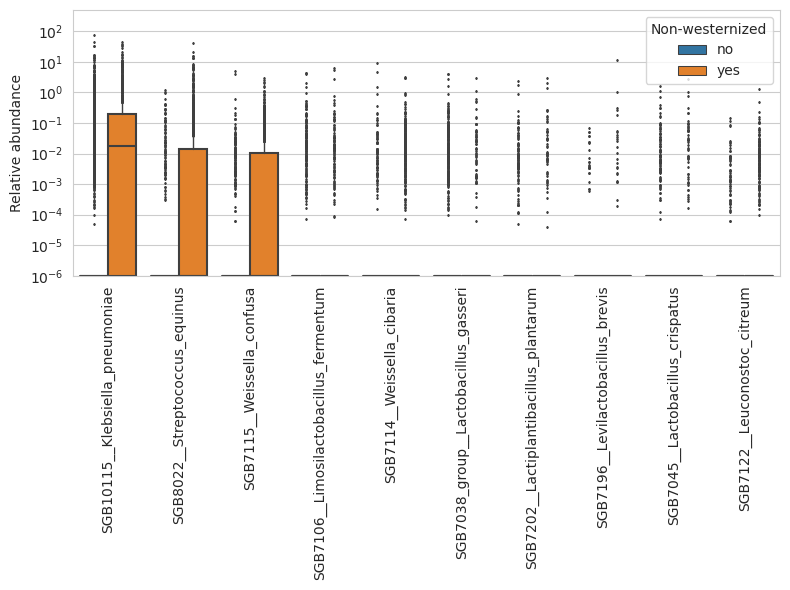

In [942]:
alc_df = meta_analysis[list(set(meta_analysis.columns).intersection(set([old2newidx[i] for i in food_sig_sets["alcohol"]])))]
alc_df = alc_df[list(alc_df.sum().sort_values(ascending=False).index)]
alc_df = alc_df[list((alc_df.max() > 1).index[(alc_df.max() > 1)])]
alc_df["non_westernized"] = meta_analysis.non_westernized

# Identify your SGB columns (all except the metadata column 'non_westernized')
sgb_cols = [c for c in alc_df.columns if c != "non_westernized"]

# Melt into long format
long_df = alc_df.melt(
    id_vars=["non_westernized"],
    value_vars=sgb_cols,
    var_name="SGB",
    value_name="abundance"
)

long_df["abundance"] += 1e-6

# Make the plot
plt.figure(figsize=(8,6))
sns.boxplot(
    data=long_df,
    x="SGB",
    y="abundance",
    hue="non_westernized",
    showcaps=False,
    whiskerprops={"linewidth":1},
    fliersize=1
)

# Beautify
plt.yscale("log")
plt.ylim([1e-6,5e2])
plt.xticks(rotation=90)
plt.ylabel("Relative abundance")
plt.xlabel("")
plt.title("")
plt.legend(title="Non-westernized")
plt.tight_layout()
plt.show()


In [940]:
def mwu_test(subdf):
    # split by group
    x = subdf.loc[subdf["non_westernized"] == "yes", "abundance"] + 1e-6
    y = subdf.loc[subdf["non_westernized"] == "no", "abundance"] + 1e-6
    
    # run Mann–Whitney U
    stat, pval = mannwhitneyu(x, y, alternative="two-sided")
    
    return pd.Series({"U": stat, "pval": pval})

long_df.groupby("SGB").apply(mwu_test).reset_index().sort_values(by="pval")

,SGB,U,pval
0,SGB10115__Klebsiella_pneumoniae,5145808.0,0.000000e+00
5,SGB7115__Weissella_confusa,4749844.5,0.000000e+00
9,SGB8022__Streptococcus_equinus,4615526.0,0.000000e+00
4,SGB7114__Weissella_cibaria,4016017.5,5.005856e-161
6,SGB7122__Leuconostoc_citreum,3763857.5,4.696315e-90
3,SGB7106__Limosilactobacillus_fermentum,3582840.5,9.636732e-19
7,SGB7196__Levilactobacillus_brevis,3450176.0,2.612531e-09
8,SGB7202__Lactiplantibacillus_plantarum,3489336.5,7.446484e-09
2,SGB7045__Lactobacillus_crispatus,3488101.5,7.608788e-09
1,SGB7038_group__Lactobacillus_gasseri,3423609.5,2.328009e-01


#### **Prevalence-based model**
Do microbiomes from NW individuals contains more/less food-associated SGBs?

In [688]:
meta_analysis_prev = pd.concat([meta_analysis[metadata_cols], meta_analysis_normalized.astype(bool).astype(int)], axis=1)

final = meta_analysis[metadata_cols].copy()

for food_cat in food_sig_sets.keys():
    foodsig = [old2newidx[i] for i in food_sig_sets[food_cat]]
    foodsig_ovl = list(set(meta_analysis.columns).intersection(foodsig))
    final["sig_"+food_cat] = meta_analysis_prev[foodsig_ovl].sum(axis=1)

final["non_westernized"] = final.non_westernized.map({"yes":1,"no":0})
final["age"] = final["age"].astype(int)
final["number_reads"] = final["number_reads"].astype(int)
final["gender"] = final["gender"].astype("category")
final["sequencing_platform"] = final["sequencing_platform"].astype("category")

final.to_csv("../data/food_modeling_data.tsv", sep="\t")

Check distribution of # food SGBs

9


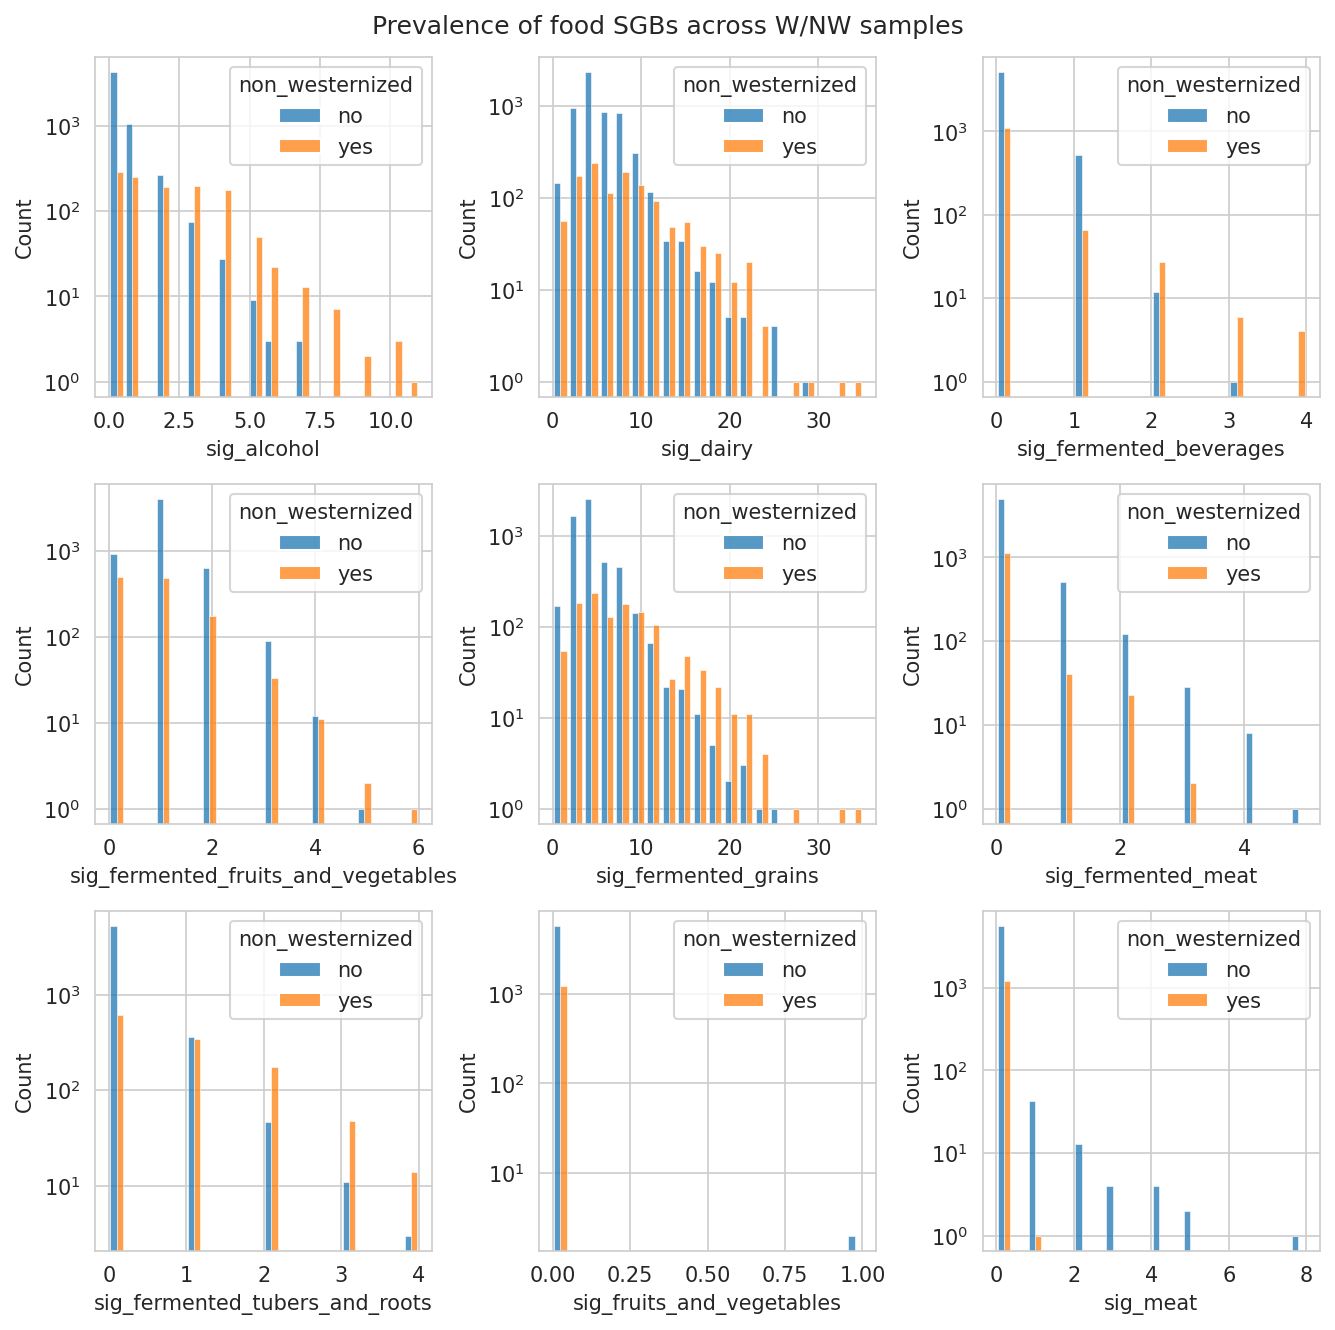

In [584]:
print(len(final.columns[7:]))

fig, axes = plt.subplots(ncols=3, nrows=3, dpi=150, figsize=(9,9))

for i, ax in zip(final.columns[7:], axes.ravel()):
    sns.histplot(data=final, x=i, hue="non_westernized", ax=ax, bins=20, multiple="dodge", shrink=.8)
    ax.set_yscale("log")

fig.suptitle("Prevalence of food SGBs across W/NW samples")
fig.tight_layout()
fig.savefig("../fig/prev_food_sgbs_wnw.png", dpi=250, bbox_inches="tight")

`statsmodels` does not have a proper model for modeling count data with random effects.

**--> Switch to R lme4 for Poisson GLMM**

In [89]:
# Results generated in R
glmm_df = pd.read_csv("../data/food_sig_glmm_results.tsv", sep="\t")

# Keep only the main variable of interest (westernization)
df_nw = glmm_df[glmm_df['parameter'] == 'non_westernizedyes'].copy()
df_nw = df_nw[df_nw.food_category!="sig_fruits_and_vegetables"]

df_nw['coef'] = np.exp(df_nw['Estimate'])
df_nw['ci_lower'] = np.exp(df_nw['ci_lower'])
df_nw['ci_upper'] = np.exp(df_nw['ci_upper'])
df_nw = df_nw.rename(columns={"Pr(>|z|)":"pval"})
df_nw["food_category"] = df_nw.food_category.apply(lambda x: " ".join(x.split("_")[1:]))

plot_coefficients(
    df_nw, 
    baseline=1,
    xlab="Multiplicative effect of non-westernized (exp(coef))",
    ylab="",
    title=f"",
    legend_loc="lower right",
    label="ME on counts (exp(coef))",
    outfile="../fig/food_glmm_prevalence"
)

NameError: name 'plot_coefficients' is not defined

## **OLD**

For every SGB, count the number of food samples in which that SGB is present.

In [39]:
food_categories = list(food_meta["category"].unique()) # all categories
samples_per_food = food_meta["category"].value_counts() # total number of samples for each food category

# Count the number of samples
allsumm = {}
for sgb in sgb_food_index:
    summ = dict(Counter(sgb_food_index[sgb]))
    for food in food_categories:
        if food not in summ:
            summ[food] = 0
    allsumm[sgb] = summ

# Store results in dataframe
df = pd.DataFrame.from_dict(allsumm, orient='index')

# Divide total sample count by total sample count (per food)
for food in food_categories:
    df[food] = df[food] / samples_per_food[food]

# Drop SGBs that are present in <10% of ANY food type
df = df[df.ge(0.10).any(axis=1)]
print(df.shape)

(831, 15)


#### SGB enrichment in food samples
To formally assign SGBs to specific food categories, we perform Fisher's exact test on every SGB-food combination.

In [46]:
food_category_totals = dict(food_meta["category"].value_counts())

df_counts = pd.DataFrame.from_dict(allsumm, orient='index')
selected_categories = [i for i in food_category_totals if food_category_totals[i] > 10]
df_counts = df_counts[selected_categories]
selected_categories_values = [food_category_totals[i] for i in selected_categories]
df_prevalence = df_counts.div(selected_categories_values, axis=1)
mask = (df_prevalence >= 0.20).any(axis=1)
df_counts = df_counts[mask]

# Total samples in dataset
total_samples = sum(food_category_totals.values())

# Store results
results = []

for sgb in df_counts.index:
    sgb_counts = df_counts.loc[sgb]
    total_sgb = sgb_counts.sum()

    # Build contingency table
    for cat in df_counts.columns:
        a = sgb_counts[cat]
        b = total_sgb - a
        c = food_category_totals[cat] - a
        d = total_samples - a - b - c
        table = [[a, b], [c, d]]
        
        # Fisher's exact test (test for overrepresentation)
        oddsratio, pval = fisher_exact(table, alternative='greater')
        
        results.append({
            'sgb': sgb,
            'category': cat,
            'a': a, 'b': b, 'c': c, 'd': d,
            'pval': pval,
            'oddsratio': oddsratio
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Optional: adjust for multiple testing (e.g., Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests

results_df['padj'] = multipletests(results_df['pval'], method='fdr_bh')[1]
max_or = results_df[results_df['oddsratio'] != float('inf')]['oddsratio'].max()
results_df['oddsratio'] = results_df['oddsratio'].replace(float('inf'), max_or)

old2newidx = {i:"__".join(re.match(r"(.+?) \((.+)\)",i).groups()[::-1]).replace(" ", "_") for i in results_df.sgb}
results_df["sgb_id"] = results_df.sgb.map(old2newidx)

print(
    "Number of significant associations detected:", 
    results_df[results_df.padj<.05].shape[0]
)

Number of significant associations detected: 708


Plot odds ratios

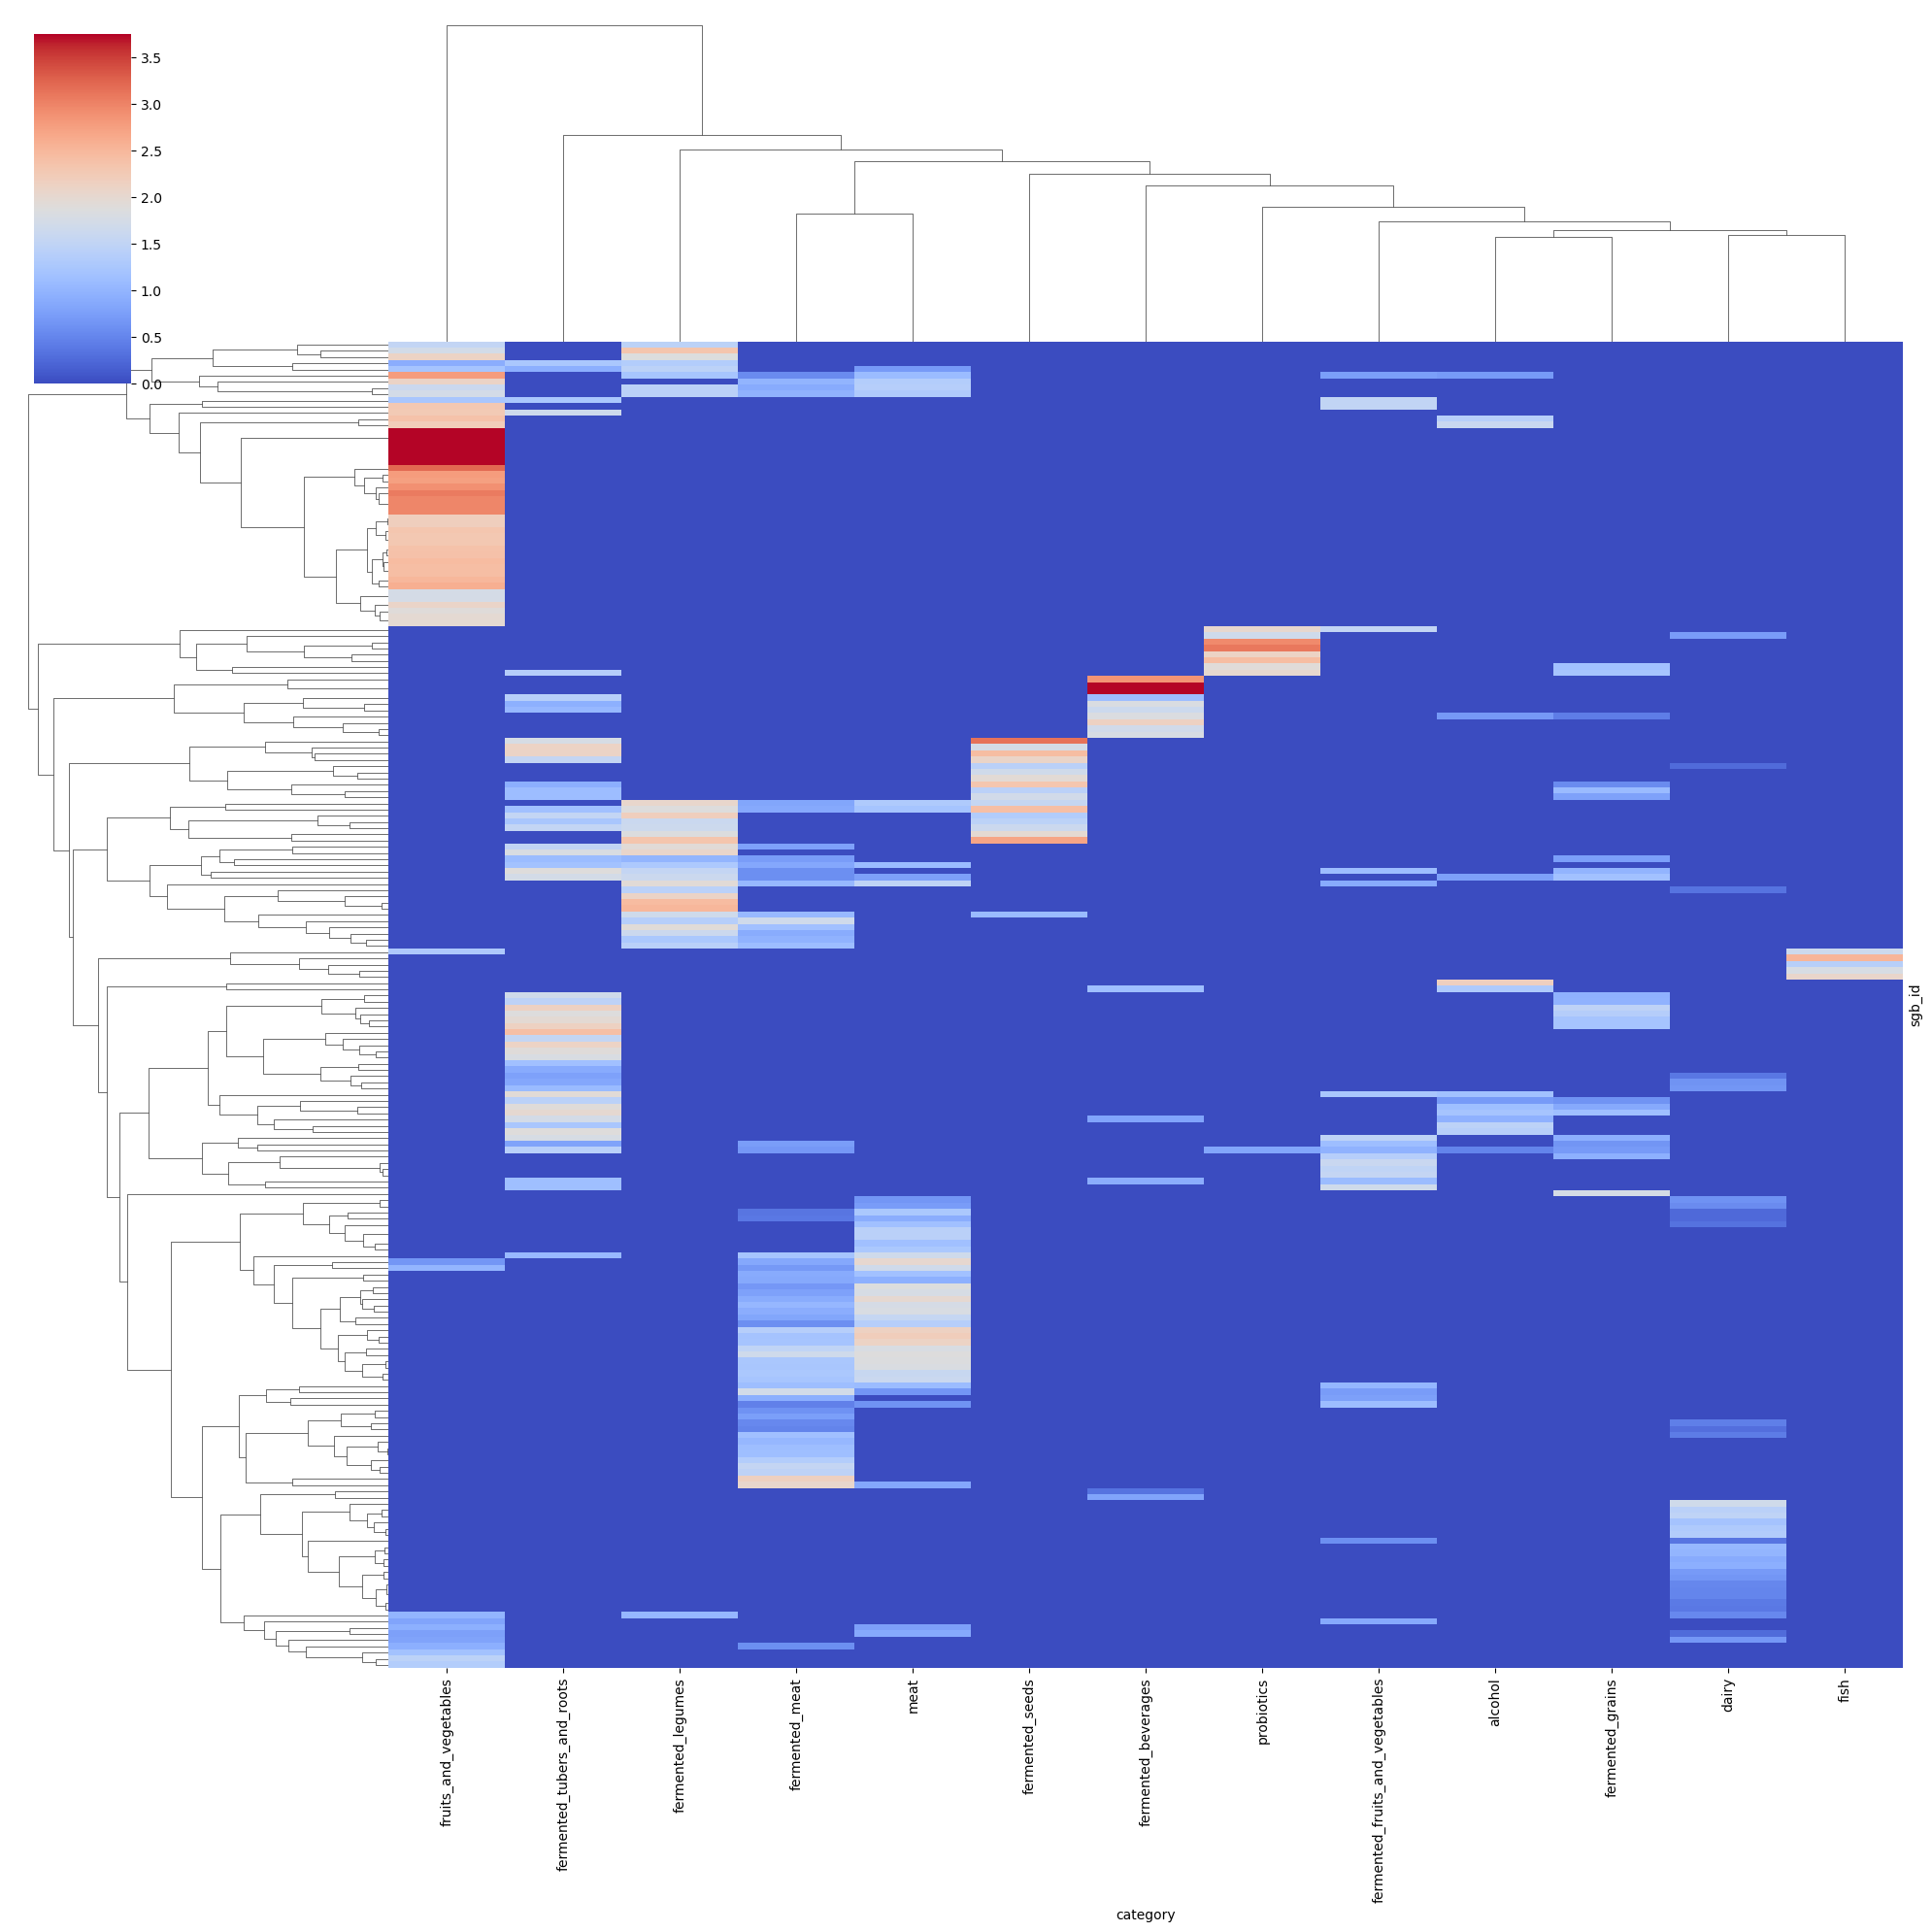

In [66]:
cols = ["sgb_id","category","oddsratio","padj"]
# Subset enrichment results to only include:
# - significant associations (adjusted p < .01)
# - SGBs that are actually present in our samples
subdf = results_df[(results_df.padj<.01) & (results_df.sgb_id.isin(meta_analysis.columns[7:]))][cols]

# Pivot to matrix form: rows = SGBs, columns = categories
heatmap_df = subdf.copy()
heatmap_df['log_odds'] = np.log10(heatmap_df['oddsratio'].replace(0, np.nan))

# Pivot
heatmap_matrix = heatmap_df.pivot(index='sgb_id', columns='category', values='log_odds')

sns.clustermap(
    heatmap_matrix.fillna(0),
    metric="euclidean", 
    method="average", 
    cmap="coolwarm", 
    figsize=(20,20),
    yticklabels=False
)

Plot the number of food associations per SGB.

/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, '# food associations per SGB')

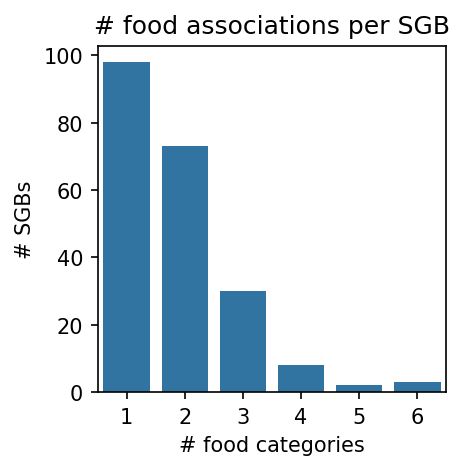

In [94]:
food_associations_per_sgb = subdf.sgb_id.value_counts().value_counts()
x = food_associations_per_sgb.index
y = food_associations_per_sgb.values

fig, ax = plt.subplots(dpi=150, figsize=(3,3))
sns.barplot(x,y,color="tab:blue")
ax.set_xlabel("# food categories")
ax.set_ylabel("# SGBs")
ax.set_title("# food associations per SGB")

Some of the species seem to be quite ubiquitous across different foods. For the sake of the analysis, it is probably better to remove them...

...but which cutoff do we use? <3?

In [118]:
# get SGB that occur less than 3 times
valid = subdf.sgb_id.value_counts()[lambda x: x < 3].index
spec_sgbs = subdf[subdf.sgb_id.isin(valid)]

print("# SGBs before filtering:", len(subdf.sgb_id.unique()))
print("# SGBs after filtering:", len(spec_sgbs.sgb_id.unique()))

# SGBs before filtering: 214
# SGBs after filtering: 171


Plot the final distribution of food associations.

/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0, 0.5, '# associated SGBs')

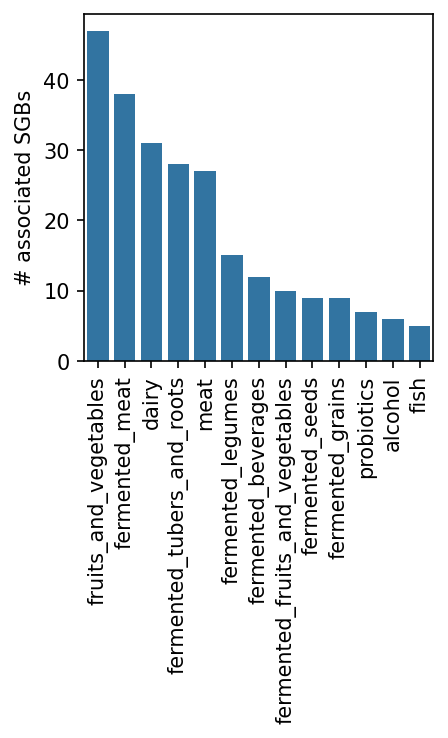

In [119]:
foods = spec_sgbs["category"].value_counts().index
nassoc = spec_sgbs["category"].value_counts().values

fig, ax = plt.subplots(dpi=150, figsize=(3,3))
sns.barplot(foods, nassoc, color="tab:blue")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_ylabel("# associated SGBs")

Show final distribution of SGBs across food types.

In [139]:
alt_ids = ["__".join(re.match(r"(.+?) \((.+)\)",i).groups()[::-1]).replace(" ", "_") for i in df.index]
df.index = alt_ids

/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/seaborn/matrix.py:1203: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 
  self._figure.tight_layout(**tight_params)


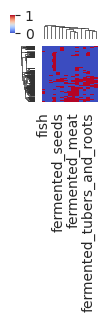

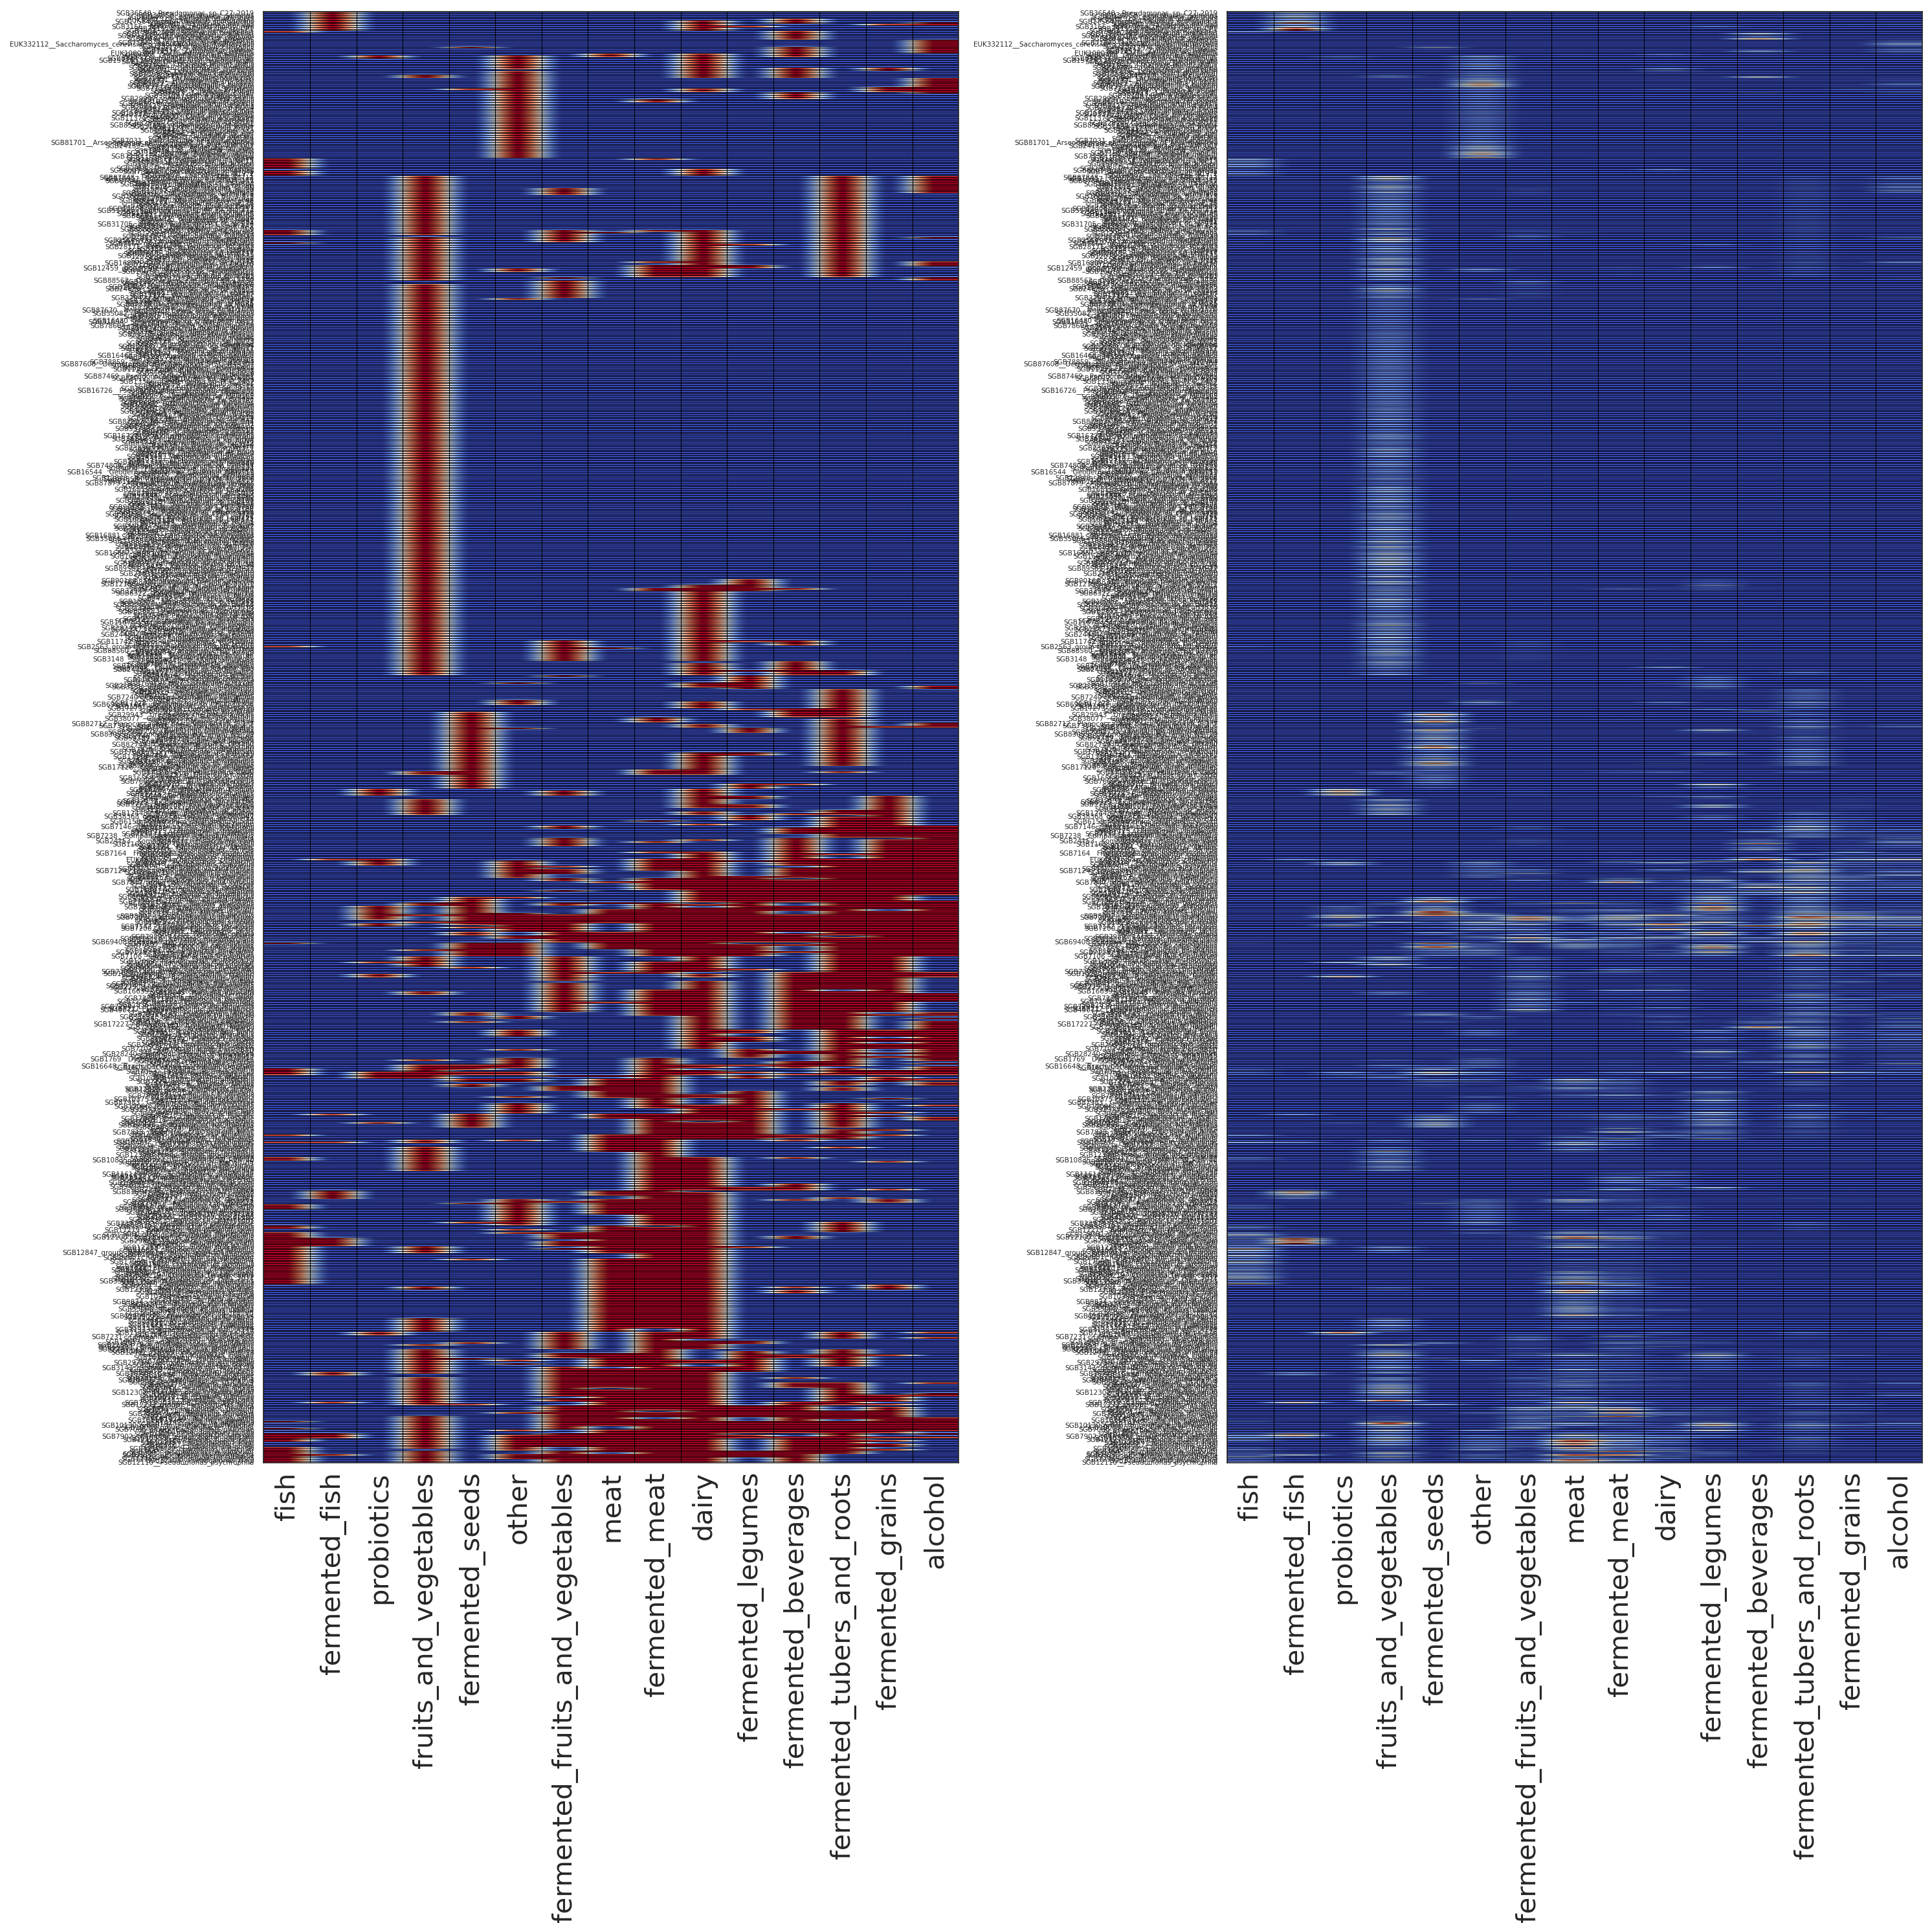

In [144]:
sns.set_style("white")

hm = sns.clustermap(df.astype(bool).astype(int), 
               metric='jaccard', 
               method='average', 
               figsize=(1,1), 
               cmap='coolwarm',
              yticklabels=False)

# Get row and column order as positional indices
row_order = hm.dendrogram_row.reordered_ind
col_order = hm.dendrogram_col.reordered_ind

# Get reordered row and column labels (SGBs and food categories)
reordered_rows = df.index[row_order]
reordered_cols = df.columns[col_order]

df = df.loc[reordered_rows]
df = df[reordered_cols]

fig, ax = plt.subplots(dpi=150, figsize=(20,20), ncols=2)
ax[0].imshow(df.astype(bool).astype(int), aspect="auto", cmap="coolwarm")
ax[1].imshow(df, aspect="auto", cmap="coolwarm")

# Show borders between cells
ax[0].set_xticks(np.arange(df.shape[1]+1)-0.5, minor=True)
ax[0].set_yticks(np.arange(df.shape[0]+1)-0.5, minor=True)
ax[0].grid(which='minor', color='black', linewidth=0.5)

# Show borders between cells
ax[1].set_xticks(np.arange(df.shape[1]+1)-0.5, minor=True)
ax[1].set_yticks(np.arange(df.shape[0]+1)-0.5, minor=True)
ax[1].grid(which='minor', color='black', linewidth=0.5)

# Hide major ticks
# ax[0].tick_params(which='major', bottom=False, left=False, labelbottom=False, labelleft=False)

ax[0].set_yticks(range(df.shape[0]))
ax[0].set_yticklabels(reordered_rows, fontsize=5)

ax[0].set_xticks(range(df.shape[1]))
ax[0].set_xticklabels(reordered_cols, fontsize=20, rotation=90, ha="center")

ax[1].set_yticks(range(df.shape[0]))
ax[1].set_yticklabels(reordered_rows, fontsize=5)

ax[1].set_xticks(range(df.shape[1]))
ax[1].set_xticklabels(reordered_cols, fontsize=20, rotation=90, ha="center")

fig.tight_layout()
# sns.clustermap(df_final_filter, 
#                figsize=(10,10), 
#                cmap='coolwarm',
#               yticklabels=False)

In [164]:
dict(df.astype(bool).astype(int).sum())

food_prev = pd.read_table("../data/wnw_food_sgb_summary.tsv")

# Group SGBs by environment
food_to_sgbs = (
    food_prev
    .groupby("food_category")["sgb_id"]
    .apply(set)
    .to_dict()
)

In [169]:
subdf

,sgb_id,category,oddsratio,padj,newidcol
0,SGB7843__Staphylococcus_equorum,dairy,2.636522,7.709115e-19,SGB7843__Staphylococcus_equorum-dairy
2,SGB7843__Staphylococcus_equorum,fermented_meat,14.228645,7.931846e-41,SGB7843__Staphylococcus_equorum-fermented_meat
15,SGB12105__Pseudomonas_fragi,fermented_meat,24.677759,1.836372e-37,SGB12105__Pseudomonas_fragi-fermented_meat
18,SGB12105__Pseudomonas_fragi,meat,141.561728,2.910261e-44,SGB12105__Pseudomonas_fragi-meat
28,SGB7517__Brochothrix_thermosphacta,fermented_meat,48.186086,2.172688e-79,SGB7517__Brochothrix_thermosphacta-fermented_meat
...,...,...,...,...,...
4908,SGB34975__Frigoribacterium_sp_PhB160,fruits_and_vegetables,5667.750000,1.039386e-11,SGB34975__Frigoribacterium_sp_PhB160-fruits_an...
5194,SGB2998__Flavobacterium_piscis,fruits_and_vegetables,5667.750000,1.019529e-09,SGB2998__Flavobacterium_piscis-fruits_and_vege...
5207,SGB7605__Planomicrobium_glaciei,fruits_and_vegetables,5667.750000,1.019529e-09,SGB7605__Planomicrobium_glaciei-fruits_and_veg...
5233,SGB7425__Paenibacillus_amylolyticus,fruits_and_vegetables,5667.750000,1.019529e-09,SGB7425__Paenibacillus_amylolyticus-fruits_and...


In [ ]:
total_sgbs_per_food_cat = dict(zip(food_prev.food_category, food_prev.n_total_samples))

res = []
for food_cat in total_sgbs_per_food_cat:

    food_cat_sgbs = set(meta_analysis.columns).intersection(food_to_sgbs[food_cat])
    sample_food_sgbs = meta_analysis[list(food_cat_sgbs)].sum(axis=1).reset_index()
    sample_food_sgbs.columns = ["sample_id","n_food_sgbs"]
    sample_food_sgbs = sample_food_sgbs.set_index("sample_id")
    sample_food_sgbs = meta_analysis[colselect].merge(sample_food_sgbs, left_index=True, right_index=True)
    sample_food_sgbs["food_category"] = food_cat
    res.append(sample_food_sgbs)

food_sgbs_per_sample = pd.concat(res)
food_sgbs_per_sample["n_total_sgbs"] = food_sgbs_per_sample.food_category.map(total_sgbs_per_food_cat)
food_sgbs_per_sample["is_nonwest_binary"] = food_sgbs_per_sample.non_westernized.map({"no":0,"yes":1})
food_sgbs_per_sample["n_unique_sgbs_in_sample"] = food_sgbs_per_sample.index.map(sample2numbersgb)

# Final parsed data to feed into model
food_sgbs_per_sample.to_csv("../data/food_sgbs_per_sample.tsv",sep="\t")
food_sgbs_per_sample.head()

**CODE REVIEWED UNTIL HERE**

## **ENVIRONMENT SGBs**

### Get SGB prevalences in different environments

In [103]:
prev_file = "/shares/CIBIO-Storage/CM/scratch/projects/ablanco_metaphlansgb/results/new_diversity/prevalences.tsv"
colnames = ["environment","sgb_id","n_present_samples","n_total_samples"]
env_prev = pd.read_table(prev_file, names=colnames)

print("All environments:\n", list(set(env_prev.environment)))

# Filter on selected environments
selected_environments = ["Rummen","Ocean","NHP","Soil","Freshwater"]
env_prev = env_prev[env_prev.environment.isin(selected_environments)]

# # SGB should be present in > 20% of env samples
# env_prev = env_prev[env_prev["n_present_samples"]/env_prev["n_total_samples"]>0.2]

All environments:
 ['NHP', 'Lab_Mice', 'Airways', 'Stool_Ancient', 'Freshwater', 'Vagina', 'Oral_NW', 'Oral_Ancient', 'Skin', 'Rummen', 'Soil', 'Ocean', 'Oral_W', 'Stool_NW', 'Wild_Mice', 'Stool_W']


#### **Environment signatures**

In [104]:
# Total number of samples per environment
total_samples_per_env = env_prev.groupby("environment")["n_total_samples"].first()
total_samples_all = total_samples_per_env.sum()

results = []

for env in env_prev["environment"].unique():
    n_samples_env = total_samples_per_env[env]
    n_samples_other = total_samples_all - n_samples_env
    
    env_df = env_prev[env_prev["environment"] == env]
    
    for _, row in env_df.iterrows():
        sgb = row["sgb_id"]
        a = row["n_present_samples"]
        c = row["n_total_samples"] - a
        
        # samples outside this env with this SGB
        b = env_prev.loc[
            (env_prev["environment"] != env) & (env_prev["sgb_id"] == sgb),
            "n_present_samples"
        ].sum()
        
        d = n_samples_other - b

        prevalence_ratio = ((a+0.5)/(a+c+1))/((b+0.5)/(b+d+1))
        
        # Run Fisher’s exact test (enrichment in this env)
        oddsratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        
        results.append({
            "environment": env,
            "sgb_id": sgb,
            "odds_ratio": oddsratio,
            "pval": pval,
            "a": a, "b": b, "c": c, "d": d,
            "prev_ratio":prevalence_ratio
        })

results_df = pd.DataFrame(results)

# Multiple testing correction (FDR)
results_df["pval_adj"] = multipletests(results_df["pval"], method="fdr_bh")[1]

min_prev = 0.10  # 10% threshold on prevalence in environment
min_ratio = 2    # effect size cutoff

results_df["prevalence_env"] = results_df["a"] / (results_df["a"] + results_df["c"])
results_df["prevalence_other"] = results_df["b"] / (results_df["b"] + results_df["d"])

signatures = results_df[
    (results_df["pval_adj"] < 0.05) &
    (results_df["prevalence_env"] >= min_prev) &
    (results_df["prevalence_env"] / (results_df["prevalence_other"]+1e-9) >= min_ratio)
]

# Final list of signature SGBs per environment
sig_dict = signatures.groupby("environment")["sgb_id"].apply(list).to_dict()

#### **Abundance model**

In [105]:
final = meta_analysis[metadata_cols].copy()
all_sgbs = set(meta_analysis.columns[7:])
for env in sig_dict.keys():
    sig_sgbs = set(sig_dict[env])
    ovl_sgbs = all_sgbs.intersection(sig_sgbs)
    final["sig_" + env] = meta_analysis[ovl_sgbs].sum(axis=1) / 100
final["non_westernized"] = final.non_westernized.map({"yes":1,"no":0})
final["age"] = final["age"].astype(int)
final["number_reads"] = final["number_reads"].astype(int)
final = final[final.gender.isin(["male","female"])]
final["gender"] = final["gender"].astype("category")
final["sequencing_platform"] = final["sequencing_platform"].astype("category")

/tmp/ipykernel_143737/2378562175.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].sum(axis=1) / 100
/tmp/ipykernel_143737/2378562175.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].sum(axis=1) / 100
/tmp/ipykernel_143737/2378562175.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].sum(axis=1) / 100
/tmp/ipykernel_143737/2378562175.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].sum(axis=1) / 100
/tmp/ipykernel_143737/2378562175.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future versi

In [106]:
signatures = [c for c in final.columns if c.startswith("sig_")]
model_results = []

for sig in signatures:
    formula = f"{sig} ~ non_westernized + age + gender + number_reads + sequencing_platform"
    md = smf.mixedlm(formula, final, groups=final["study_name"]).fit()
    cat_res = pd.concat([md.params, md.bse, md.pvalues], axis=1)
    cat_res = cat_res.reset_index()
    cat_res.columns = ["parameter","coef","stderr","pval"]
    cat_res["ci_upper"] = cat_res["coef"].astype(float) + cat_res["stderr"].astype(float)
    cat_res["ci_lower"] = cat_res["coef"].astype(float) - cat_res["stderr"].astype(float)
    cat_res["environment"] = sig[4:]
    model_results.append(cat_res)

model_results_df = pd.concat(model_results)

remap_env = {
    "NHP":"non-human primates",
    "Freshwater":"freshwater",
    "Ocean":"ocean",
    "Soil":"soil",
    "Rummen":"rumen"
}

model_results_df["environment"] = model_results_df["environment"].map(remap_env)
model_results_df = model_results_df[model_results_df["environment"]!="soil"]

# # Overlap with these SGBs is too small to draw meaningful conclusions
# # --> remove
# model_results_df = model_results_df[model_results_df.food_category != "fruits_and_vegetables"]
# model_results_df["food_category"] = model_results_df.food_category.apply(lambda x: " ".join(x.split("_")))

/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/hom

In [108]:
model_results_df.to_csv("../data/lmem_abundance_environment.tsv", sep="\t", index=False)

In [109]:
model_results_df

,parameter,coef,stderr,pval,ci_upper,ci_lower,environment
0,Intercept,2.484566e-03,3.200150e-03,4.375185e-01,5.684716e-03,-7.155841e-04,freshwater
1,gender[T.male],-1.517469e-03,9.879074e-04,1.245277e-01,-5.295612e-04,-2.505376e-03,freshwater
2,sequencing_platform[T.IlluminaNextSeq],-2.958563e-04,8.003062e-03,9.705106e-01,7.707206e-03,-8.298918e-03,freshwater
3,sequencing_platform[T.IlluminaNovaSeq],1.316425e-02,6.525673e-03,4.366411e-02,1.968992e-02,6.638574e-03,freshwater
4,non_westernized,9.686121e-03,4.075979e-03,1.748292e-02,1.376210e-02,5.610142e-03,freshwater
5,age,9.357673e-05,3.713992e-05,1.174974e-02,1.307167e-04,5.643681e-05,freshwater
6,number_reads,3.592091e-11,2.370454e-11,1.296814e-01,5.962545e-11,1.221636e-11,freshwater
7,Group Var,1.109144e-01,2.537358e-02,1.235344e-05,1.362880e-01,8.554080e-02,freshwater
0,Intercept,3.306081e-01,1.325500e-02,2.598698e-137,3.438631e-01,3.173531e-01,non-human primates
1,gender[T.male],-6.738995e-03,3.163469e-03,3.315058e-02,-3.575526e-03,-9.902464e-03,non-human primates


In [107]:
utils.plot_coefficients(
    model_results_df[model_results_df["parameter"] == "non_westernized"],
    category_col="environment",
    ylab="",
    xlab="",
    title="",
    outfile="../fig/env_lmm_abundance"
)

NameError: name 'plot_coefficients' is not defined

In [864]:
sig_dict["NHP"]

890

#### **Prevalence model**

In [833]:
final = meta_analysis[metadata_cols].copy()
all_sgbs = set(meta_analysis.columns[7:])
for env in sig_dict.keys():
    sig_sgbs = set(sig_dict[env])
    ovl_sgbs = all_sgbs.intersection(sig_sgbs)
    final["sig_" + env] = meta_analysis[ovl_sgbs].astype(bool).astype(int).sum(axis=1)
final["non_westernized"] = final.non_westernized.map({"yes":1,"no":0})
final["age"] = final["age"].astype(int)
final["number_reads"] = final["number_reads"].astype(int)
final["gender"] = final["gender"].astype("category")
final["sequencing_platform"] = final["sequencing_platform"].astype("category")

final.to_csv("../data/env_modeling_data.tsv", sep="\t")

/tmp/ipykernel_573010/3532539836.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].astype(bool).astype(int).sum(axis=1)
/tmp/ipykernel_573010/3532539836.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].astype(bool).astype(int).sum(axis=1)
/tmp/ipykernel_573010/3532539836.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].astype(bool).astype(int).sum(axis=1)
/tmp/ipykernel_573010/3532539836.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  final["sig_" + env] = meta_analysis[ovl_sgbs].astype(bool).astype(int).sum(axis=1)
/tmp/ipykernel_573010/3532539836.py:6: FutureWarning

5


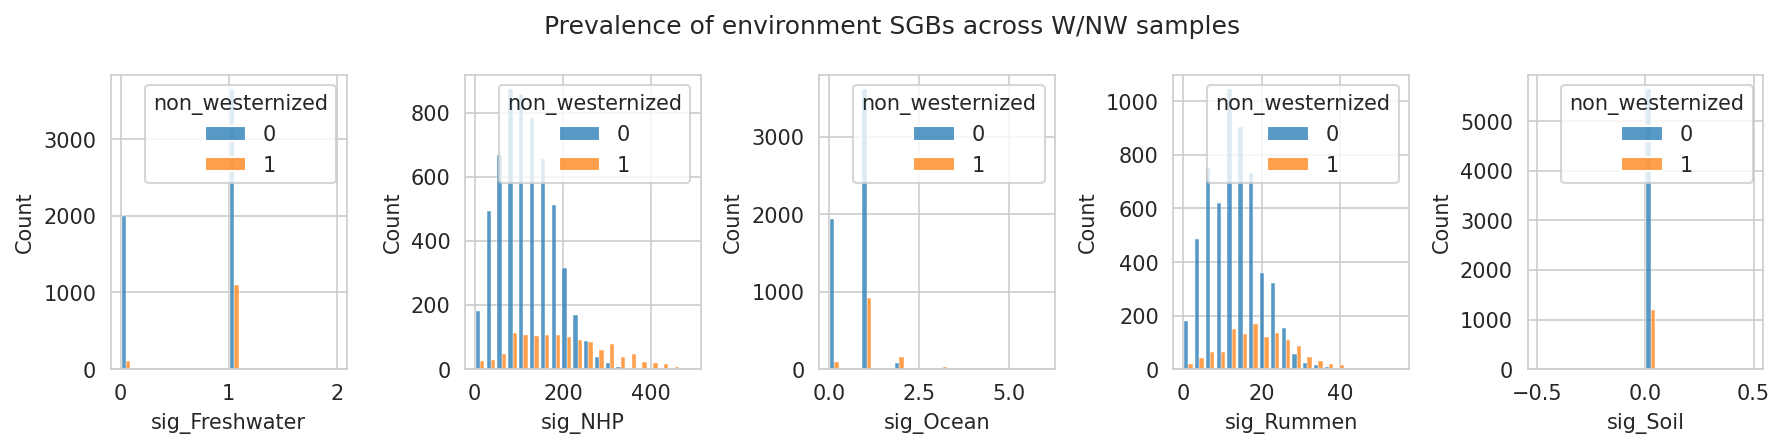

In [834]:
print(len(final.columns[7:]))

fig, axes = plt.subplots(ncols=5, nrows=1, dpi=150, figsize=(12,3))

for i, ax in zip(final.columns[7:], axes.ravel()):
    sns.histplot(data=final, x=i, hue="non_westernized", ax=ax, bins=20, multiple="dodge", shrink=.8)
    # ax.set_yscale("log")

fig.suptitle("Prevalence of environment SGBs across W/NW samples")
fig.tight_layout()
fig.savefig("../fig/prev_env_sgbs_wnw.png", dpi=250, bbox_inches="tight")

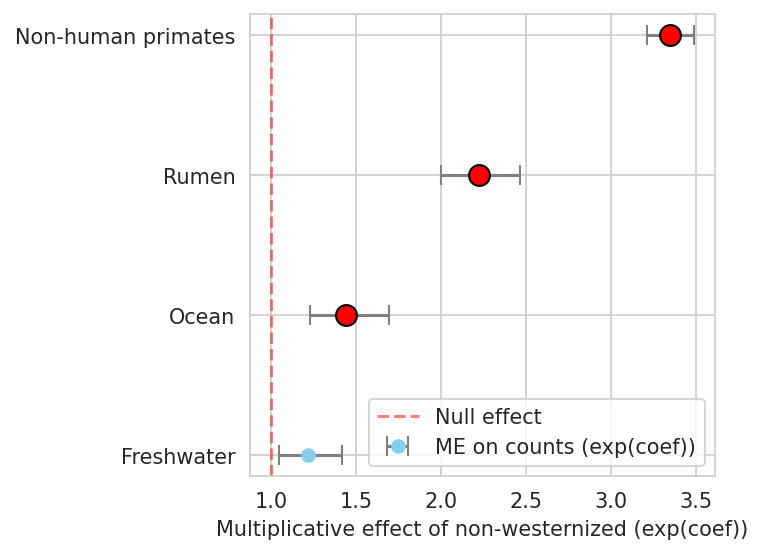

In [836]:
# Results generated in R
glmm_df = pd.read_csv("../data/env_sig_glmm_results.tsv", sep="\t")

# Keep only the main variable of interest (westernization)
df_nw = glmm_df[glmm_df['parameter'] == 'non_westernizedyes'].copy()
# df_nw = df_nw[df_nw.food_category!="sig_fruits_and_vegetables"]

df_nw['coef'] = np.exp(df_nw['Estimate'])
df_nw['ci_lower'] = np.exp(df_nw['ci_lower'])
df_nw['ci_upper'] = np.exp(df_nw['ci_upper'])
df_nw = df_nw.rename(columns={"Pr(>|z|)":"pval"})
df_nw["food_category"] = df_nw.food_category.apply(lambda x: " ".join(x.split("_")[1:]))

df_nw["food_category"] = df_nw.food_category.map(
    {"NHP":"Non-human primates","Rummen":"Rumen","Ocean":"Ocean","Freshwater":"Freshwater"}
)

plot_coefficients(
    df_nw, 
    baseline=1,
    xlab="Multiplicative effect of non-westernized (exp(coef))",
    ylab="",
    title=f"",
    legend_loc="lower right",
    label="ME on counts (exp(coef))",
    outfile="../fig/env_glmm_prevalence"
)

In [14]:
sample2numbersgb = dict(meta_analysis[list(meta_analysis.columns[7:])].astype(bool).astype(int).sum(axis=1))

def prep_model_data(
    meta_analysis, 
    env_to_sgbs, 
    environment="Rummen"
):

    cumulative_abundance = meta_analysis[list(env_to_sgbs[environment])].sum(axis=1)
    cumulative_prevalence = meta_analysis[list(env_to_sgbs[environment])].astype(bool).astype(int).sum(axis=1)
    
    final = meta_analysis[target_col + confounders]
    final["abundance"] = cumulative_abundance
    final["prevalence"] = cumulative_prevalence
    final["richness"] = final.index.map(sample2numbersgb)
    final["presence_absence"] = final.prevalence.astype(bool).astype(int)
    
    final["abundance_prop"] = (final["abundance"] / 100) + 1e-06
    final["log_abundance"] = np.log(final["abundance_prop"])
    final["logit_abundance"] = np.log(final["abundance_prop"] / (1 - final["abundance_prop"]))

    print(final.shape[0])
    print(final[final.abundance == 0].shape[0])
    
    fig, ax = plt.subplots(dpi=150, figsize=(9,3), ncols=3)
    sns.histplot(final["abundance_prop"], bins=100, kde=True, ax=ax[0])
    sns.histplot(final["log_abundance"], bins=100, kde=True, ax=ax[1])
    sns.histplot(final["logit_abundance"], bins=100, kde=True, ax=ax[2])  # logit
    ax[0].set_title("Raw abundances")
    ax[1].set_title("Log-scaled")
    ax[2].set_title("Logit")
    fig.tight_layout()
    fig.show()

    return final

NameError: name 'meta_analysis' is not defined

In [15]:
all_env_sgbs = []

for l in env_to_sgbs.values():
    all_env_sgbs = all_env_sgbs + list(l)

all_env_sgbs = list(set(all_env_sgbs))

ovl = set(meta_analysis.columns[7:]).intersection(all_env_sgbs)
env_meta_analysis = meta_analysis[list(meta_analysis.columns[:7]) + list(ovl)]

NameError: name 'meta_analysis' is not defined

In [217]:
gut_df = prevs_sum.reset_index().rename(columns={prevs_sum.index.name or 'index': 'sgb_id'})

W = len(w)
NW = len(nw)

results = []

for env, sgb_set in env_to_sgbs.items():
    sgb_subset = gut_df[gut_df["sgb_id"].isin(sgb_set)]

    # Count how many environment-specific SGBs are found in NW and W
    present_in_nw = (sgb_subset["present_nw"] > 0).sum()
    present_in_w = (sgb_subset["present_w"] > 0).sum()

    # Total number of environment SGBs tested
    total_in_env = len(sgb_subset)
    
    # Count SGBs not found in that gut group
    absent_in_nw = total_in_env - present_in_nw
    absent_in_w = total_in_env - present_in_w

    # Build contingency table (W vs NW)
    table = [[present_in_nw, absent_in_nw],
             [present_in_w, absent_in_w]]

    # Fisher's Exact Test (use odds ratio, p-value)
    oddsratio, pval = fisher_exact(table)

    # Store results
    results.append({
        "environment": env,
        "n_sgbs": total_in_env,
        "present_nw": present_in_nw,
        "present_w": present_in_w,
        "oddsratio": oddsratio,
        "pval": pval
    })

results_df = pd.DataFrame(results)

# FDR correction
results_df["fdr_pval"] = multipletests(results_df["pval"], method="fdr_bh")[1]
results_df = results_df.sort_values("fdr_pval")

In [219]:
def compute_or_ci(a, b, c, d):
    # Avoid divide-by-zero by adding 0.5 to zero cells (Haldane-Anscombe correction)
    if 0 in [a, b, c, d]:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    or_val = (a * d) / (b * c)
    log_or = np.log(or_val)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_lower = np.exp(log_or - 1.96 * se)
    ci_upper = np.exp(log_or + 1.96 * se)

    return or_val, se, ci_lower, ci_upper

or_vals = []
ses = []
ci_lowers = []
ci_uppers = []

for _, row in results_df.iterrows():
    a = row["present_nw"]
    b = row["n_sgbs"] - a
    c = row["present_w"]
    d = row["n_sgbs"] - c

    or_val, se, ci_lo, ci_hi = compute_or_ci(a, b, c, d)

    or_vals.append(or_val)
    ses.append(se)
    ci_lowers.append(ci_lo)
    ci_uppers.append(ci_hi)

results_df["oddsratio_corrected"] = or_vals
results_df["log_or_se"] = ses
results_df["ci_lower"] = ci_lowers
results_df["ci_upper"] = ci_uppers

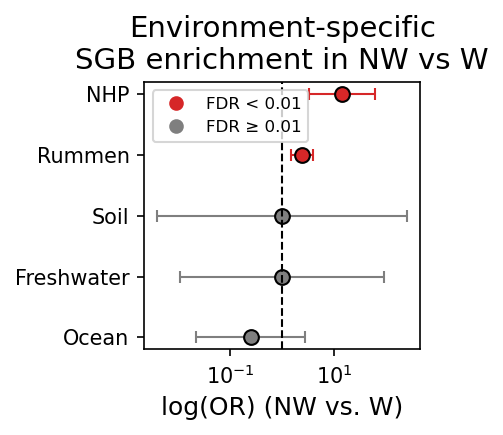

In [220]:
# Sort by odds ratio
results_df_sorted = results_df.sort_values("oddsratio_corrected", ascending=True).reset_index(drop=True)

# Assign binary color based on FDR p-value
colors = results_df_sorted["fdr_pval"].apply(lambda p: "tab:red" if p < 0.01 else "tab:gray")

# Plot
fig, ax = plt.subplots(figsize=(3,3),dpi=150)

for i, (or_val, ci_low, ci_up, color) in enumerate(zip(
    results_df_sorted["oddsratio_corrected"],
    results_df_sorted["ci_lower"],
    results_df_sorted["ci_upper"],
    colors
)):
    ax.errorbar(
        x=or_val,
        y=i,
        xerr=[[or_val - ci_low], [ci_up - or_val]],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=3,
        markersize=6,
        # edgecolor="k",
        linestyle='none',
        linewidth=1,
        zorder=0
    )

    ax.scatter(
        x=or_val,
        y=i,
        color=color,
        edgecolor="k",
        linewidths=1,
        zorder=1,
        s=50
        # edgecolor="k",
    )


# Replace index with environment labels
ax.set_yticks(range(len(results_df_sorted)))
ax.set_yticklabels(results_df_sorted["environment"])

# Log-scale x-axis
ax.set_xscale("log")
ax.set_xlabel("log(OR) (NW vs. W)", fontsize=12)
# ax.set_ylabel("Environment", fontsize=12)
ax.set_title("Environment-specific\nSGB enrichment in NW vs W", fontsize=14)

# Add vertical reference line
ax.axvline(1, color='k', linestyle='--', linewidth=1)


# Add manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='tab:red', label='FDR < 0.01', linestyle=''),
    Line2D([0], [0], marker='o', color='tab:gray', label='FDR ≥ 0.01', linestyle='')
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=8)

fig.tight_layout()

def save_figure(fig, path, dpi=500):
    fig.savefig(path+".png",dpi=500,format="png",bbox_inches="tight")
    fig.savefig(path+".pdf",dpi=500,format="pdf",bbox_inches="tight")
    fig.savefig(path+".svg",format="svg",bbox_inches="tight")

save_figure(fig, "../fig/environment_logodds")
plt.show()


In [225]:
metarefjan21 = "/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/"
sgbtable = pd.read_table(os.path.join(metarefjan21,"SGB.Jan21.txt.bz2"), compression="bz2", comment='#')

In [1485]:
meta_analysis

,non_westernized,study_name,age,gender,sequencing_platform,DNA_extraction_kit,number_reads,SGB1626__Prevotella_copri_clade_A,SGB4290__Ruminococcus_sp_NSJ_71,SGB5117__Coprococcus_eutactus,...,SGB32233__Aquamicrobium_defluvii,SGB64172__Jeotgalibaca_porci,SGB10725__Paracoccus_solventivorans,SGB32666__Paracandidimonas_soli,SGB10726__Paracoccus_alkenifer,SGB28493__Arcobacter_trophiarum,SGB89540__Aquamicrobium_lusatiense,SGB8530__Proteiniborus_ethanoligenes,SGB87720__Propioniciclava_sp_MC1595,SGB11414__Bosea_sp_WAO
O2_UC49_0,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,60584637.0,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC49_2,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,56508214.0,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_0,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,65105855.0,0.99226,7.81511,0.05737,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_2,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,53260679.0,0.00000,5.32192,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC51_0,no,NielsenHB_2014,32.0,female,IlluminaHiSeq,unknown,57486896.0,0.00000,0.00000,4.03200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,yes,CM_tanzania,20.0,male,IlluminaHiSeq,Qiagen,38426298.0,8.29545,2.73756,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20645-TZ,yes,CM_tanzania,34.0,female,IlluminaHiSeq,Qiagen,66130906.0,7.22606,0.04019,0.00293,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20646-TZ,yes,CM_tanzania,40.0,male,IlluminaHiSeq,Qiagen,66850184.0,6.61441,0.01647,0.03258,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20647-TZ,yes,CM_tanzania,18.0,female,IlluminaHiSeq,Qiagen,62136875.0,0.68483,0.00000,0.21350,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **FOOD SGBs**
Are NW/W gut microbiomes enriched for certain food-related SGBs? To study this we will have a look at food metagenomics studies in [curatedFoodMetagenomicData](https://github.com/SegataLab/cFMD).

### **Food metadata**

In [784]:
food_meta = pd.read_table("../data/cFMD_metadata.tsv")
data_dir = "/shares/CIBIO-Storage/CM/scratch/data/meta/"

datasets = food_meta.dataset_name.unique()
check = {}

# For each study, check if Jan21 MetaPhlan4 profiles are present
for dataset in datasets:
    dataset_root = os.path.join(data_dir, dataset)
    # Ensure the dataset directory exists
    if not os.path.exists(dataset_root):
        check[dataset] = (False, None)
        continue
    try:
        subdirs = os.listdir(dataset_root)
        metaphlan_dirs = [
            d for d in subdirs
            if "metaphlan-4" in d and "Jan21" in d
        ]
        if metaphlan_dirs:
            # Take the first match (or all if you want)
            matched_dir = metaphlan_dirs[0]
            check[dataset] = (True, matched_dir)
        else:
            check[dataset] = (False, None)
    except Exception as e:
        check[dataset] = (False, None)

# Only keep studies that have the Jan21 MetaPhlan4 profiles
check_df = pd.DataFrame(check).T
check_df.columns = ["has_jan21_profiles", "sample_dir"]
check_df = check_df[check_df.has_jan21_profiles]
selected_studies = check_df.index
print(f"Datasets with Jan21 profiles: {len(selected_studies)}/{len(datasets)}")
dataset2sampledir = dict(zip(check_df.index,check_df.sample_dir))
food_meta = food_meta[food_meta.dataset_name.isin(selected_studies)]

# Assign path to Jan21 MetaPhlan4 profiles
profile_paths = []
for i in food_meta.index:
    dataset = food_meta.loc[i].dataset_name
    sample_root = dataset2sampledir[dataset]
    sample_id = food_meta.loc[i].sample_id
    profile_id = f"{sample_id}_profile.tsv"
    profile_paths.append(os.path.join(data_dir,dataset,sample_root,sample_id,profile_id))

food_meta["profile_path"] = profile_paths

Datasets with Jan21 profiles: 59/85


In [1141]:
food_meta.head(2)

,dataset_name,sample_id,macrocategory,category,type,subtype,commercial_name,fermented/non-fermented,country,sample_accession,...,mean_read_len,max_read_len,n_contigs,n_MAGs_MQ_prok,n_MAGs_HQ_prok,n_MAGs_MQ_euk,n_MAGs_HQ_euk,filtered,curator,profile_path
0,AlvarezOrdonezA_xxxx,C01-16,food,meat,cured_meat_before_ripening,cured_meat_before_ripening,NaN,NF,ESP,SAMN36689796,...,146.200505,151.0,62700,0,0,0,0,no,Niccolò_Carlino,/shares/CIBIO-Storage/CM/scratch/data/meta/Alv...
1,AlvarezOrdonezA_xxxx,C01-17,food,meat,cured_meat_before_ripening,cured_meat_before_ripening,NaN,NF,ESP,SAMN36689797,...,147.266426,151.0,98756,0,0,0,0,no,Niccolò_Carlino,/shares/CIBIO-Storage/CM/scratch/data/meta/Alv...


### **Assign SGBs to food type**
If we find an SGB in a certain food sample, assign that food to that SGB.

In [48]:
cols = ["sgb_id","category","oddsratio","padj"]
subdf = results_df[(results_df.padj<.01) & (results_df.sgb_id.isin(meta_analysis.columns[7:]))][cols]

# Pivot to matrix form: rows = SGBs, columns = categories
heatmap_df = subdf.copy()
heatmap_df['log_odds'] = np.log10(heatmap_df['oddsratio'].replace(0, np.nan))

# Filter: only show SGBs with padj < 0.05 in at least one category
sig_sgbs = heatmap_df[heatmap_df['padj'] < 0.05]['sgb_id'].unique()
filtered = heatmap_df[heatmap_df['sgb_id'].isin(sig_sgbs)]

# Pivot
heatmap_matrix = filtered.pivot(index='sgb_id', columns='category', values='log_odds')

sns.clustermap(heatmap_matrix.fillna(0),
               metric="euclidean", 
               method="average", 
               cmap="coolwarm", 
               figsize=(10, 10),
              yticklabels=False)

# # Plot
# plt.figure(figsize=(12, 10))
# sns.heatmap(heatmap_matrix, cmap='coolwarm', center=0, cbar_kws={'label': 'log10(odds ratio)'})
# plt.title("Enrichment/depletion (log10 OR) of SGBs by food category")
# plt.tight_layout()
# plt.show()

NameError: name 'sns' is not defined

In [ ]:
print("n significant associations:", subdf.shape[0])
print("n unique SGBs:", subdf.sgb_id.nunique())

subdf["newidcol"] = subdf.sgb_id + "-" + subdf.category
food_prev["newidcol"] = food_prev.sgb_id + "-" + food_prev.food_category

merged = food_prev.reset_index(drop=True).merge(subdf.reset_index(drop=True), on=["newidcol","sgb_id"])
merged = merged.drop(columns = ["category","newidcol","pvalue","evalue"])

merged

Text(0, 0.5, 'n unique SGBs')

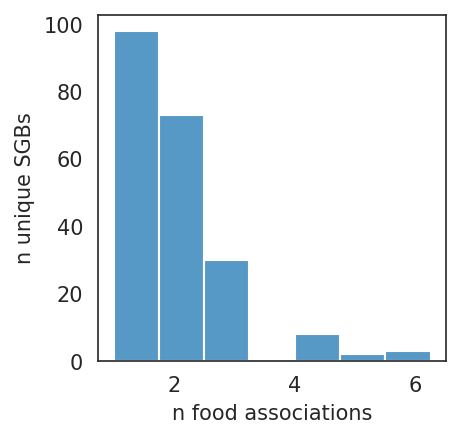

In [1459]:
fig, ax = plt.subplots(dpi=150,figsize=(3,3))
sns.histplot(merged.sgb_id.value_counts(), binwidth=.75)
ax.set_xlabel("n food associations")
ax.set_ylabel("n unique SGBs")

Text(0, 0.5, 'n associated SGBs')

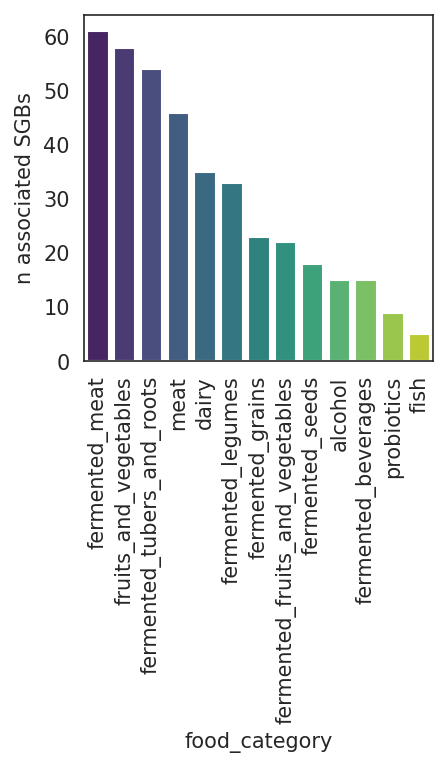

In [1475]:
fig, ax = plt.subplots(dpi=150,figsize=(3,3))

# Get value counts as a DataFrame
counts = merged.food_category.value_counts().reset_index()
counts.columns = ['food_category', 'count']

sns.barplot(data=counts, x='food_category', y='count', palette='viridis')

plt.xticks(rotation=90, ha='center')
plt.ylabel('n associated SGBs')
# plt.xlabel('Food Category')
# plt.title('Sample Count per Food Category')
# plt.tight_layout()
# plt.show()


In [1457]:
merged.to_csv("../data/sgb_food_asscociations_filtered.tsv", sep="\t", index=False)

In [1240]:
food_categories = list(food_meta["category"].unique())
samples_per_food = food_meta["category"].value_counts()

from collections import Counter

allsumm = {}
for sgb in sgb_food_cat_index:
    summ = dict(Counter(sgb_food_cat_index[sgb]))
    for food in food_categories:
        if food not in summ:
            summ[food] = 0
    allsumm[sgb] = summ

df = pd.DataFrame.from_dict(allsumm, orient='index')

for food in food_categories:
    df[food] = df[food] / samples_per_food[food]

df = df[df.ge(0.10).any(axis=1)]

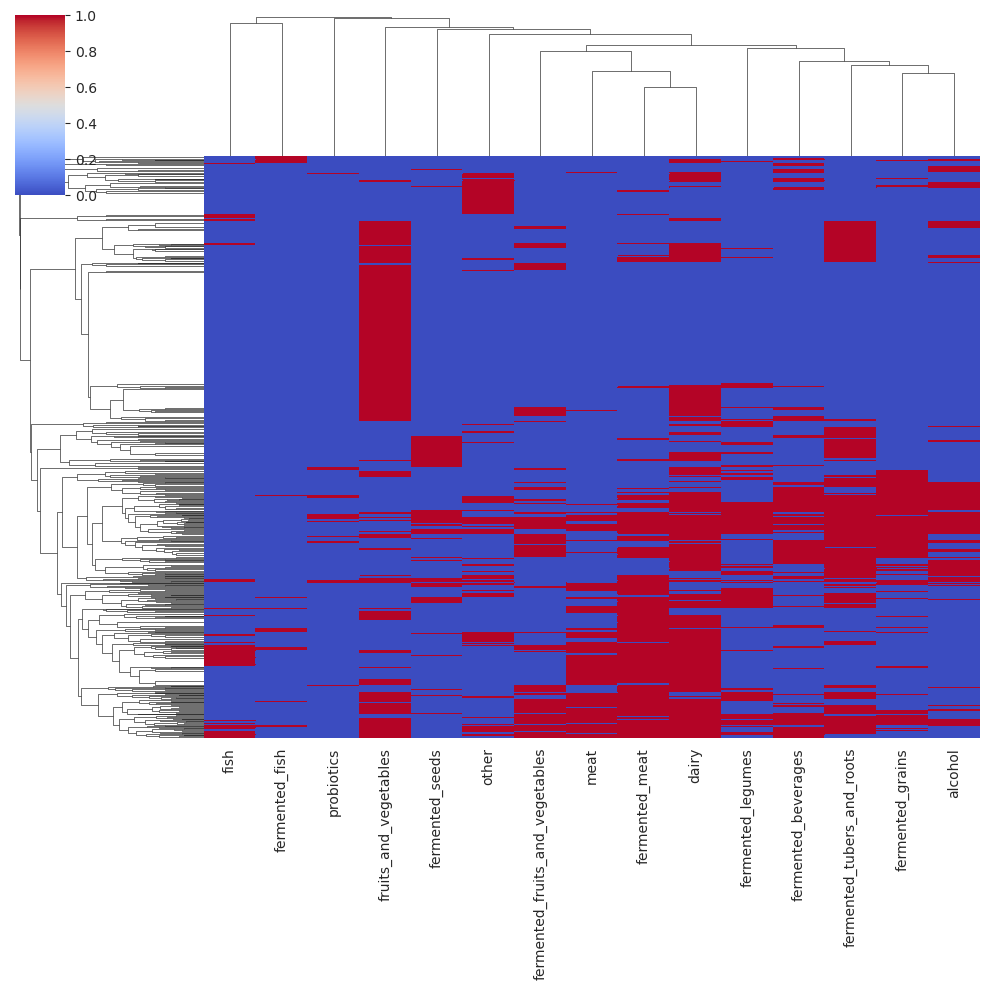

In [1242]:
import seaborn as sns

# sns.clustermap(, cmap="coolwarm")

# Cluster with seaborn
sns.clustermap(df.astype(bool).astype(int), 
               metric='jaccard', 
               method='average', 
               figsize=(10,10), 
               cmap='coolwarm',
               yticklabels=False)

/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


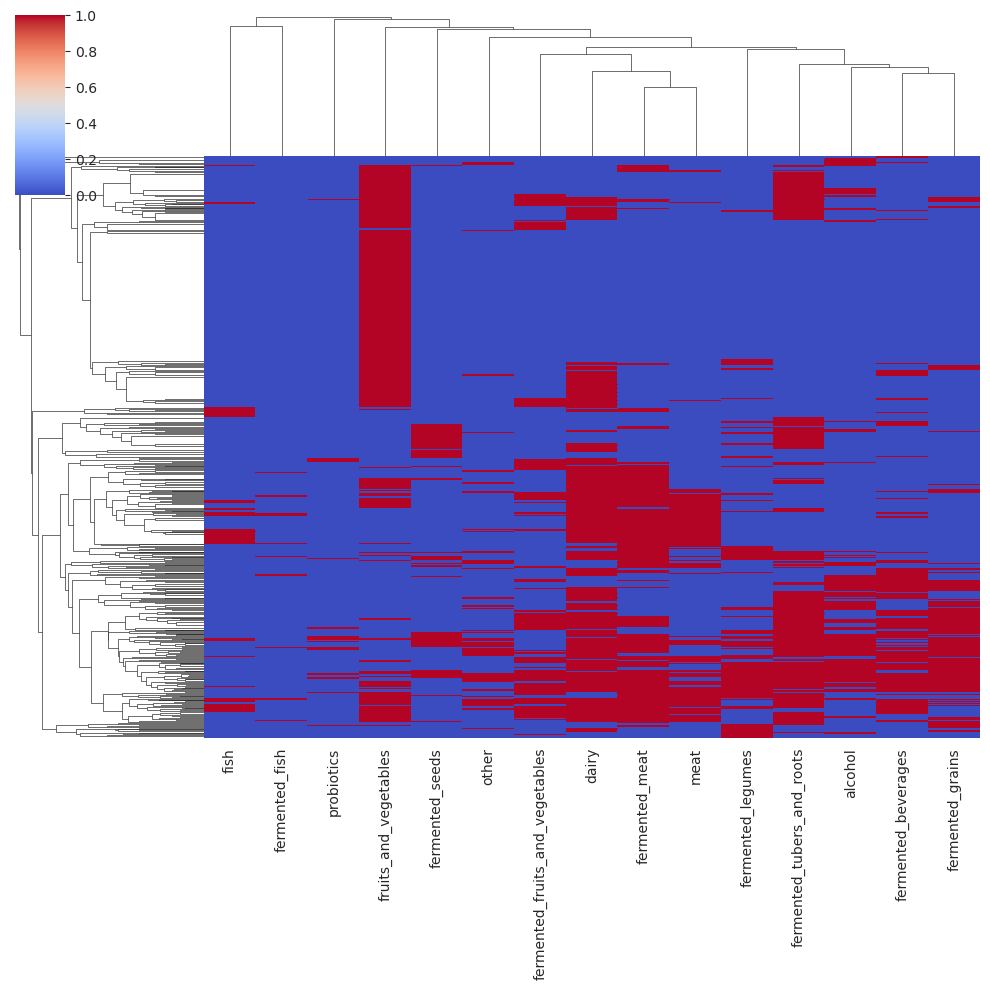

In [1243]:
sign_association = food_prev[food_prev.evalue<.01].sgb_id.unique()

alt_ids = ["__".join(re.match(r"(.+?) \((.+)\)",i).groups()[::-1]).replace(" ", "_") for i in df.index]
df["alt_name"] = alt_ids

df_filtered = df[df.alt_name.isin(sign_association)].drop(columns=["alt_name"])

sns.clustermap(df_filtered.astype(bool).astype(int), 
               metric='jaccard', 
               method='average', 
               figsize=(10,10), 
               cmap='coolwarm',
               yticklabels=False)

In [1289]:
df_final_filter.shape[0]

322

/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/seaborn/matrix.py:1203: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 
  self._figure.tight_layout(**tight_params)


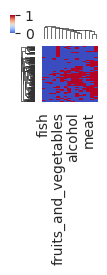

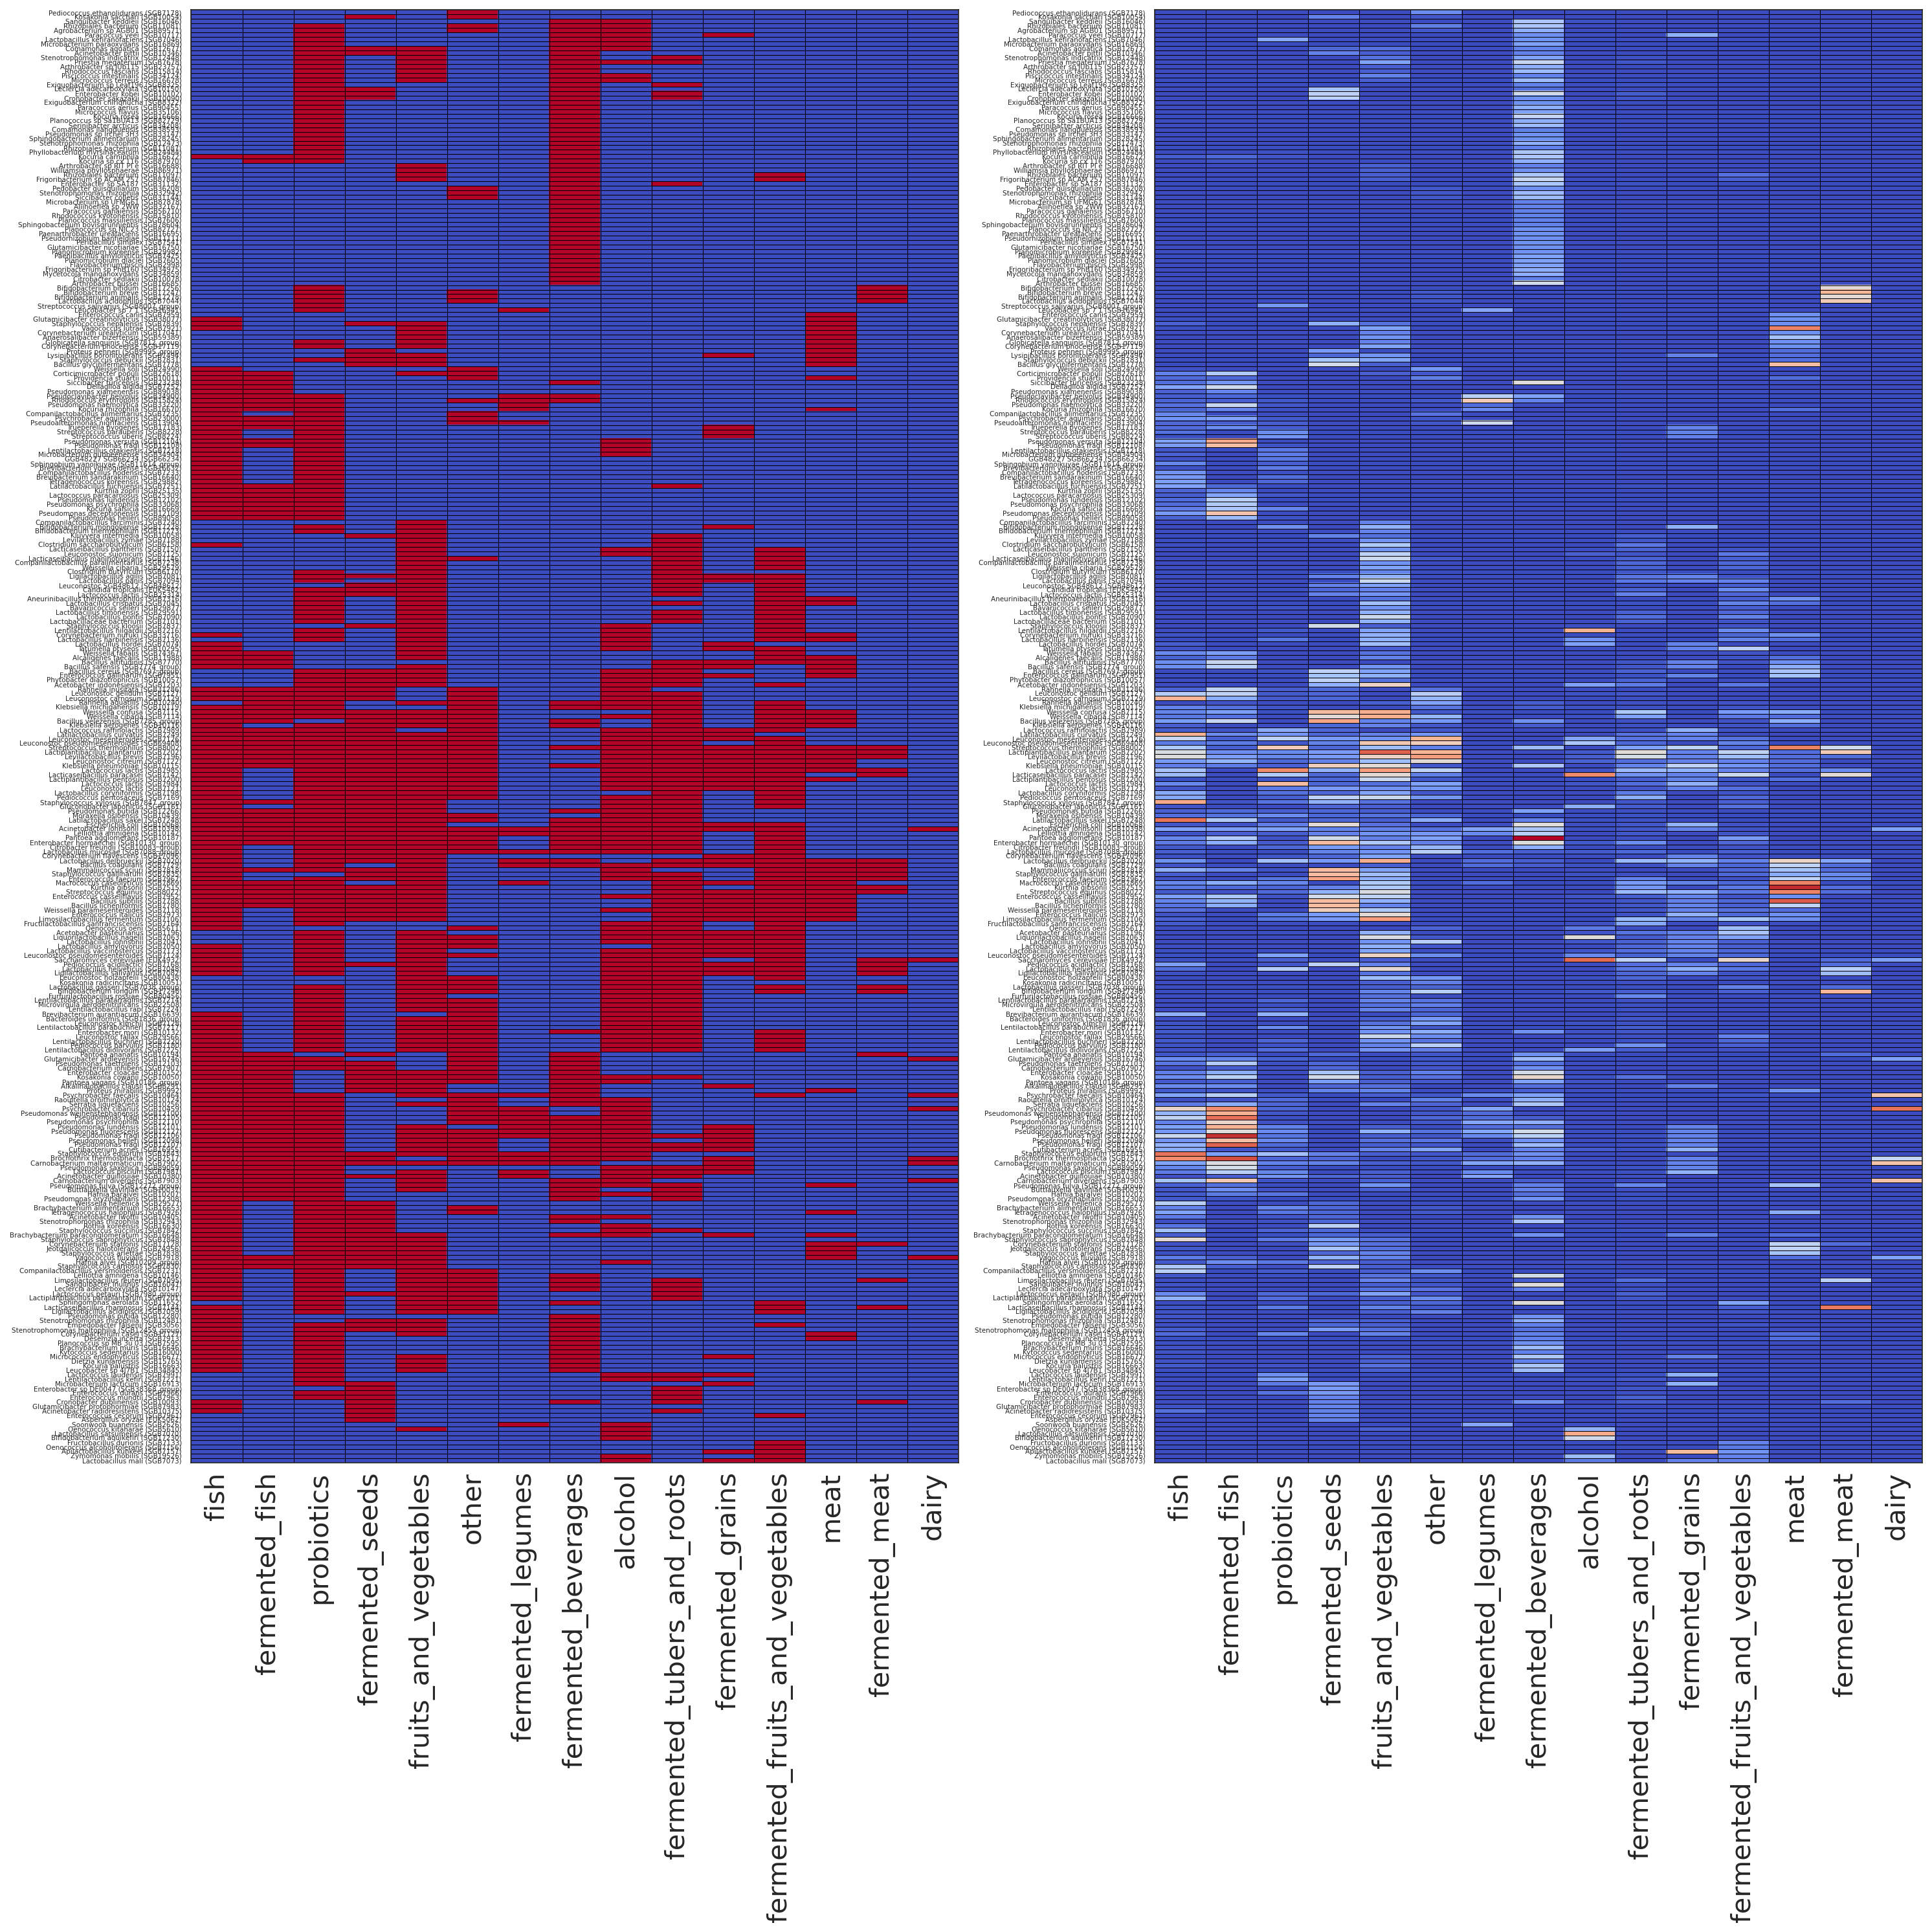

In [1301]:
sns.set_style("white")

ovl = set(meta_analysis.columns[7:]).intersection(df.alt_name)
df_final_filter = df[(df.alt_name.isin(sign_association)) & (df.alt_name.isin(ovl))].drop(columns=["alt_name"])

hm = sns.clustermap(df_final_filter.astype(bool).astype(int), 
               metric='jaccard', 
               method='average', 
               figsize=(1,1), 
               cmap='coolwarm',
              yticklabels=False)

# Get row and column order as positional indices
row_order = hm.dendrogram_row.reordered_ind
col_order = hm.dendrogram_col.reordered_ind

# Get reordered row and column labels (SGBs and food categories)
reordered_rows = df_final_filter.index[row_order]
reordered_cols = df_final_filter.columns[col_order]

df_final_filter = df_final_filter.loc[reordered_rows]
df_final_fitler = df_final_filter[reordered_cols]

fig, ax = plt.subplots(dpi=150, figsize=(20,20), ncols=2)
ax[0].imshow(df_final_filter.astype(bool).astype(int), aspect="auto", cmap="coolwarm")
ax[1].imshow(df_final_filter, aspect="auto", cmap="coolwarm")

# Show borders between cells
ax[0].set_xticks(np.arange(df_final_filter.shape[1]+1)-0.5, minor=True)
ax[0].set_yticks(np.arange(df_final_filter.shape[0]+1)-0.5, minor=True)
ax[0].grid(which='minor', color='black', linewidth=0.5)

# Show borders between cells
ax[1].set_xticks(np.arange(df_final_filter.shape[1]+1)-0.5, minor=True)
ax[1].set_yticks(np.arange(df_final_filter.shape[0]+1)-0.5, minor=True)
ax[1].grid(which='minor', color='black', linewidth=0.5)

# Hide major ticks
# ax[0].tick_params(which='major', bottom=False, left=False, labelbottom=False, labelleft=False)

ax[0].set_yticks(range(df_final_filter.shape[0]))
ax[0].set_yticklabels(reordered_rows, fontsize=5)

ax[0].set_xticks(range(df_final_filter.shape[1]))
ax[0].set_xticklabels(reordered_cols, fontsize=20, rotation=90, ha="center")

ax[1].set_yticks(range(df_final_filter.shape[0]))
ax[1].set_yticklabels(reordered_rows, fontsize=5)

ax[1].set_xticks(range(df_final_filter.shape[1]))
ax[1].set_xticklabels(reordered_cols, fontsize=20, rotation=90, ha="center")

fig.tight_layout()
# sns.clustermap(df_final_filter, 
#                figsize=(10,10), 
#                cmap='coolwarm',
#               yticklabels=False)

In [1304]:
fig.savefig("../fig/sgbs_per_food_category.png", format="png", dpi=300)

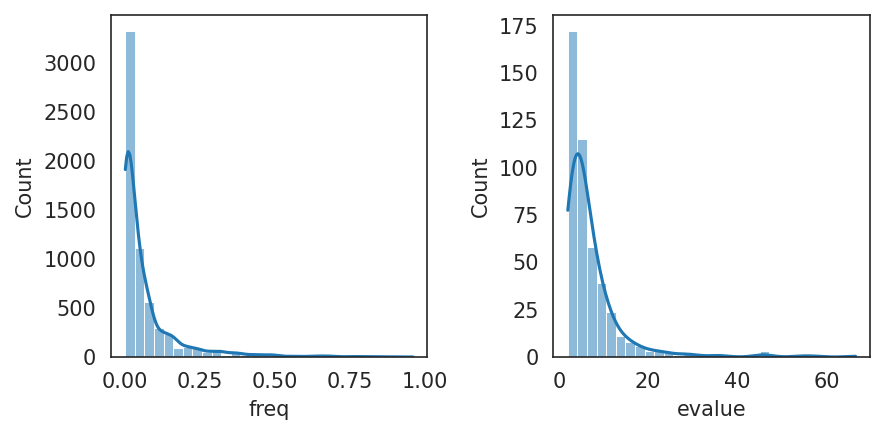

In [1342]:
fig, ax = plt.subplots(dpi=150, figsize=(6,3), ncols=2)
sns.histplot(food_prev.freq, bins=30, kde=True, ax=ax[0])

food_prev_filtered = food_prev[
    (food_prev.evalue<.01) & \
    (food_prev.freq>.1) & \
    (food_prev.sgb_id.isin(list(meta_analysis.columns[7:])))
]

sns.histplot(-np.log10(food_prev_filtered.evalue), bins=30, kde=True, ax=ax[1])

fig.tight_layout()

#### Goal

For every **SGB** in the dictionary, count how many times it appears in samples from a specific **food category**.

#### Example Input

```python
{
  'Staphylococcus equorum (SGB7843)': ['meat', 'meat', 'meat', 'dairy']
}
```
#### Example output

| sgb\_id                          | food\_category | n\_present\_samples | n\_total\_samples |
| -------------------------------- | -------------- | ------------------- | ----------------- |
| Staphylococcus equorum (SGB7843) | meat           | 3                   | 50                |
| Staphylococcus equorum (SGB7843) | dairy          | 1                   | 78                |

`n_present_samples`: Number of samples of that food category where the SGB is found.

`n_total_samples`: Total number of samples for that food category (you would provide this separately, e.g., from metadata).

In [1129]:
all_dfs = []
for sgb in sgb_food_index:
    sgb_food_df = pd.Series(sgb_food_index[sgb]).value_counts().reset_index()
    sgb_food_df.columns = ["food_category","n_present_samples"]
    sgb_food_df["sgb_id"] = sgb
    all_dfs.append(sgb_food_df)

food_prev = pd.concat(all_dfs).reset_index(drop=True)
totals = dict(food_meta["category"].value_counts())
food_prev["n_total_samples"] = food_prev["food_category"].map(totals)

print("Total number of unique SGBs in each food categories (samples combined):")
print(totals)

# food type should have at least 10 samples
food_prev = food_prev[food_prev.n_total_samples > 10]

alt_ids = ["__".join(re.match(r"(.+?) \((.+)\)",i).groups()[::-1]).replace(" ", "_") for i in food_prev.sgb_id]
food_prev["sgb_id"] = alt_ids

print("\nNumber of SGB-food combinations after filtering:", food_prev.shape[0])
food_prev.head()

Total number of unique SGBs in each food categories (samples combined):
{'dairy': 1650, 'fermented_beverages': 422, 'fermented_meat': 133, 'fermented_grains': 80, 'alcohol': 48, 'meat': 47, 'fermented_fruits_and_vegetables': 34, 'fruits_and_vegetables': 25, 'fermented_tubers_and_roots': 24, 'fermented_legumes': 16, 'fish': 14, 'probiotics': 14, 'fermented_seeds': 13, 'other': 8, 'fermented_fish': 5}

Number of SGB-food combinations after filtering: 6215


,food_category,n_present_samples,sgb_id,n_total_samples
0,dairy,500,SGB7843__Staphylococcus_equorum,1650
1,fermented_meat,106,SGB7843__Staphylococcus_equorum,133
2,meat,9,SGB7843__Staphylococcus_equorum,47
3,fruits_and_vegetables,4,SGB7843__Staphylococcus_equorum,25
4,fermented_legumes,2,SGB7843__Staphylococcus_equorum,16


#### **Removing "generalist" species**
Some SGBs are commonly present across a variety of food categories, and should therefore be removed from the analysis.

Two ways of dealing with this problem:
1. Compute shannon entropy per species across the food categories and only select low entropy species (= abundant in only 1 or 2 food categories).
2. Perform enrichment analysis for every food-category/SGB pair and select significant ones.

#### Entropy-based
(**This does not seem to work very well, can be ignored**)

(6215, 5)


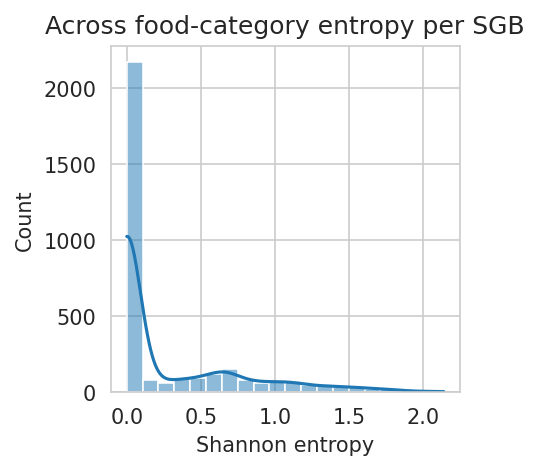

In [1130]:
def shannon_entropy(freqs):
    freqs = np.array(freqs)
    freqs = freqs[freqs > 0]  # remove zeros to avoid log(0)
    freqs = freqs / freqs.sum()  # normalize to probabilities if not already
    return -np.sum(freqs * np.log(freqs))

food_prev["freq"] = food_prev.n_present_samples/food_prev.n_total_samples 
sgb_entropy = food_prev.groupby("sgb_id").freq.apply(shannon_entropy)

fig, ax = plt.subplots(dpi=150, figsize=(3,3))
sns.histplot(sgb_entropy, bins=20, kde=True)
ax.set_xlabel("Shannon entropy")
ax.set_title("Across food-category entropy per SGB")
# freqs = example.n_present_samples/example.n_total_samples

specialists = list(sgb_entropy[sgb_entropy < 0.8].index)
# food_prev = food_prev[food_prev.sgb_id.isin(specialists)]
print(food_prev.shape)


#### Enrichment-based

6215
1376


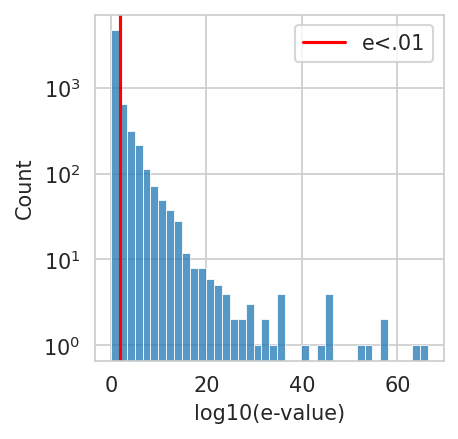

In [1131]:
ntotal_sgbs = food_prev[["food_category","n_total_samples"]].drop_duplicates().n_total_samples.sum()

pvals = []
for sgb in food_prev.sgb_id.unique():
    sgb_df = food_prev[food_prev.sgb_id==sgb]
    sgb_in_all_foods = sgb_df.n_present_samples.sum()
    for _, row in sgb_df.iterrows():
        table = [[row.n_present_samples,row.n_total_samples],[sgb_in_all_foods,ntotal_sgbs]]
        oddsr, p = fisher_exact(table)
        pvals.append(p)

evals = fdrcorrection(pvals)
food_prev["pvalue"] = pvals
food_prev["evalue"] = evals[1]

print(food_prev.shape[0])
print(food_prev[food_prev.evalue < .01].shape[0])

fig, ax = plt.subplots(dpi=150,figsize=(3,3))
sns.histplot(-np.log10(food_prev["evalue"]), bins=40)
ax.axvline(-np.log10(0.01),c="red",label="e<.01")
ax.set_yscale("log")
ax.set_xlabel("log10(e-value)")
ax.legend()

# food_prev = food_prev[food_prev.evalue < .01]

#### **IMPORTANT:** also filter out very low sample size associations

In [1139]:
# food_prev = food_prev[food_prev["n_present_samples"]/food_prev["n_total_samples"]>0.1]
food_prev.to_csv("../data/wnw_food_sgb_summary.tsv", sep="\t", index=False)

In [1098]:
food_prev.food_category.value_counts()

fruits_and_vegetables              346
fermented_tubers_and_roots          90
meat                                85
fermented_meat                      70
fermented_legumes                   61
fermented_seeds                     52
alcohol                             39
fermented_fruits_and_vegetables     37
fermented_beverages                 33
dairy                               27
fish                                25
fermented_grains                    16
probiotics                           8
Name: food_category, dtype: int64

In [1099]:
# Group SGBs by environment
food_to_sgbs = (
    food_prev
    .groupby("food_category")["sgb_id"]
    .apply(set)
    .to_dict()
)

### **Food enrichment** (ignore)
Grouped approach --> **ignore**

In [437]:
results = []

for food, sgb_set in food_to_sgbs.items():
    sgb_subset = gut_df[gut_df["sgb_id"].isin(sgb_set)]

    # Count how many environment-specific SGBs are found in NW and W
    present_in_nw = (sgb_subset["present_nw"] > 0).sum()
    present_in_w = (sgb_subset["present_w"] > 0).sum()

    # Total number of environment SGBs tested
    total_in_env = len(sgb_subset)
    
    # Count SGBs not found in that gut group
    absent_in_nw = total_in_env - present_in_nw
    absent_in_w = total_in_env - present_in_w

    # Build contingency table (W vs NW)
    table = [[present_in_nw, absent_in_nw],
             [present_in_w, absent_in_w]]

    # Fisher's Exact Test (use odds ratio, p-value)
    oddsratio, pval = fisher_exact(np.array(table) + 1)

    # Store results
    results.append({
        "food_type": food,
        "n_sgbs": total_in_env,
        "present_nw": present_in_nw,
        "present_w": present_in_w,
        "oddsratio": oddsratio,
        "pval": pval
    })

results_df = pd.DataFrame(results)

# FDR correction
results_df["fdr_pval"] = multipletests(results_df["pval"], method="fdr_bh")[1]
results_df = results_df.sort_values("fdr_pval")

In [438]:
or_vals = []
ses = []
ci_lowers = []
ci_uppers = []

for _, row in results_df.iterrows():
    a = row["present_nw"]
    b = row["n_sgbs"] - a
    c = row["present_w"]
    d = row["n_sgbs"] - c

    or_val, se, ci_lo, ci_hi = compute_or_ci(a, b, c, d)

    or_vals.append(or_val)
    ses.append(se)
    ci_lowers.append(ci_lo)
    ci_uppers.append(ci_hi)

results_df["oddsratio_corrected"] = or_vals
results_df["log_or_se"] = ses
results_df["ci_lower"] = ci_lowers
results_df["ci_upper"] = ci_uppers

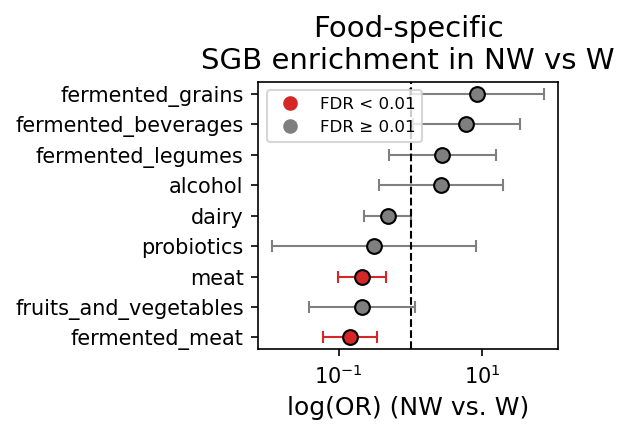

In [443]:
# Sort by odds ratio
results_df_sorted = results_df.sort_values("oddsratio_corrected", ascending=True).reset_index(drop=True)

# Assign binary color based on FDR p-value
colors = results_df_sorted["fdr_pval"].apply(lambda p: "tab:red" if p < 0.01 else "tab:gray")

# Plot
fig, ax = plt.subplots(figsize=(4,3),dpi=150)

for i, (or_val, ci_low, ci_up, color) in enumerate(zip(
    results_df_sorted["oddsratio_corrected"],
    results_df_sorted["ci_lower"],
    results_df_sorted["ci_upper"],
    colors
)):
    ax.errorbar(
        x=or_val,
        y=i,
        xerr=[[or_val - ci_low], [ci_up - or_val]],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=3,
        markersize=6,
        # edgecolor="k",
        linestyle='none',
        linewidth=1,
        zorder=0
    )

    ax.scatter(
        x=or_val,
        y=i,
        color=color,
        edgecolor="k",
        linewidths=1,
        zorder=1,
        s=50
        # edgecolor="k",
    )


# Replace index with environment labels
ax.set_yticks(range(len(results_df_sorted)))
ax.set_yticklabels(results_df_sorted["food_type"])

# Log-scale x-axis
ax.set_xscale("log")
ax.set_xlabel("log(OR) (NW vs. W)", fontsize=12)
# ax.set_ylabel("Environment", fontsize=12)
ax.set_title("Food-specific\nSGB enrichment in NW vs W", fontsize=14)

# Add vertical reference line
ax.axvline(1, color='k', linestyle='--', linewidth=1)


# Add manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='tab:red', label='FDR < 0.01', linestyle=''),
    Line2D([0], [0], marker='o', color='tab:gray', label='FDR ≥ 0.01', linestyle='')
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=8)

fig.tight_layout()

def save_figure(fig, path, dpi=500):
    fig.savefig(path+".png",dpi=500,format="png",bbox_inches="tight")
    fig.savefig(path+".pdf",dpi=500,format="pdf",bbox_inches="tight")
    fig.savefig(path+".svg",format="svg",bbox_inches="tight")

save_figure(fig, "../fig/food_category_logodds")
plt.show()


#### Meta-analysis

In [1124]:
ancient_adult_prevs.T

,SGB1626__Prevotella_copri_clade_A,SGB4290__Ruminococcus_sp_NSJ_71,SGB5117__Coprococcus_eutactus,SGB4260__GGB3226_SGB4260,SGB15234__Ruminococcaceae_unclassified_SGB15234,SGB1814__Phocaeicola_vulgatus,SGB2318__Alistipes_putredinis,SGB5825_group__Dialister_invisus,SGB15332_group__Faecalibacterium_prausnitzii,SGB6571__Bacilli_unclassified_SGB6571,...,SGB32233__Aquamicrobium_defluvii,SGB64172__Jeotgalibaca_porci,SGB10725__Paracoccus_solventivorans,SGB32666__Paracandidimonas_soli,SGB10726__Paracoccus_alkenifer,SGB28493__Arcobacter_trophiarum,SGB89540__Aquamicrobium_lusatiense,SGB8530__Proteiniborus_ethanoligenes,SGB87720__Propioniciclava_sp_MC1595,SGB11414__Bosea_sp_WAO
2611_merged,1,1,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2612_Plus,1,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2604_merged,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2610_merged,1,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2180a_merged,1,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,1,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
C16-20645-TZ,1,1,1,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
C16-20646-TZ,1,1,1,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
C16-20647-TZ,1,0,1,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [1526]:
method = "abundance"

# Potential confounding variables
# to take into account in model
confounders = [
    'study_name',
    'age',
    'gender',
    'sequencing_platform',
    'DNA_extraction_kit',
    'number_reads'
    ]

# Outcome variable
target_col = ['non_westernized']

colselect = target_col + confounders

if method == "prevalence":
    counts_table = ancient_adult_prevs.T.copy()
elif method == "abundance":
    counts_table = ancient_adult_abundances.copy()
    
print(f"{method} table:", counts_table.shape[0])
print("metadata table:", ancient_adult_metadata.shape[0])

# Parsing
meta_analysis = ancient_adult_metadata[colselect].merge(counts_table, left_index=True, right_index=True)
# meta_analysis = meta_analysis[meta_analysis.study_name.isin(valid_studies)] # remove mixed studies
meta_analysis = meta_analysis[meta_analysis.non_westernized.isin(["yes","no"])] # remove ancient samples
meta_analysis["DNA_extraction_kit"] = meta_analysis["DNA_extraction_kit"].fillna("unknown")
meta_analysis["gender"] = meta_analysis["gender"].fillna("unknown")

abundance table: 6888
metadata table: 6892


In [1128]:
meta_analysis.to_csv("../data/wnw_abundance_meta.tsv",sep="\t")
meta_analysis.head()

,non_westernized,study_name,age,gender,sequencing_platform,DNA_extraction_kit,number_reads,SGB1626__Prevotella_copri_clade_A,SGB4290__Ruminococcus_sp_NSJ_71,SGB5117__Coprococcus_eutactus,...,SGB32233__Aquamicrobium_defluvii,SGB64172__Jeotgalibaca_porci,SGB10725__Paracoccus_solventivorans,SGB32666__Paracandidimonas_soli,SGB10726__Paracoccus_alkenifer,SGB28493__Arcobacter_trophiarum,SGB89540__Aquamicrobium_lusatiense,SGB8530__Proteiniborus_ethanoligenes,SGB87720__Propioniciclava_sp_MC1595,SGB11414__Bosea_sp_WAO
O2_UC49_0,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,60584637.0,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC49_2,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,56508214.0,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_0,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,65105855.0,0.99226,7.81511,0.05737,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_2,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,53260679.0,0.00000,5.32192,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC51_0,no,NielsenHB_2014,32.0,female,IlluminaHiSeq,unknown,57486896.0,0.00000,0.00000,4.03200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


NameError: name 'food_prev' is not defined

In [1102]:
sample2numbersgb = dict(meta_analysis[list(meta_analysis.columns[7:])].sum(axis=1))

In [1103]:
total_sgbs_per_food_cat = dict(zip(food_prev.food_category, food_prev.n_total_samples))

res = []
for food_cat in total_sgbs_per_food_cat:

    food_cat_sgbs = set(meta_analysis.columns).intersection(food_to_sgbs[food_cat])
    sample_food_sgbs = meta_analysis[list(food_cat_sgbs)].sum(axis=1).reset_index()
    sample_food_sgbs.columns = ["sample_id","n_food_sgbs"]
    sample_food_sgbs = sample_food_sgbs.set_index("sample_id")
    sample_food_sgbs = meta_analysis[colselect].merge(sample_food_sgbs, left_index=True, right_index=True)
    sample_food_sgbs["food_category"] = food_cat
    res.append(sample_food_sgbs)

food_sgbs_per_sample = pd.concat(res)
food_sgbs_per_sample["n_total_sgbs"] = food_sgbs_per_sample.food_category.map(total_sgbs_per_food_cat)
food_sgbs_per_sample["is_nonwest_binary"] = food_sgbs_per_sample.non_westernized.map({"no":0,"yes":1})
food_sgbs_per_sample["n_unique_sgbs_in_sample"] = food_sgbs_per_sample.index.map(sample2numbersgb)

# Final parsed data to feed into model
food_sgbs_per_sample.to_csv("../data/food_sgbs_per_sample.tsv",sep="\t")
food_sgbs_per_sample.head()

,non_westernized,study_name,age,gender,sequencing_platform,DNA_extraction_kit,number_reads,n_food_sgbs,food_category,n_total_sgbs,is_nonwest_binary,n_unique_sgbs_in_sample
O2_UC49_0,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,60584637.0,1,fermented_meat,133,0,189
O2_UC49_2,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,56508214.0,1,fermented_meat,133,0,319
O2_UC50_0,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,65105855.0,0,fermented_meat,133,0,461
O2_UC50_2,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,53260679.0,0,fermented_meat,133,0,302
O2_UC51_0,no,NielsenHB_2014,32.0,female,IlluminaHiSeq,unknown,57486896.0,2,fermented_meat,133,0,343


Checking some numbers to see if we can exclude low occurrence confounders to simplify the model.

e.g. when variable is present in < 20 samples --> remove samples with that variable

In [1072]:
adults_metadata.sequencing_platform.value_counts()

IlluminaHiSeq      5130
IlluminaNovaSeq    1516
IlluminaNextSeq     217
Name: sequencing_platform, dtype: int64

In [1021]:
adults_metadata.DNA_extraction_kit.value_counts()

Qiagen                   2379
PowerSoilPro             1098
Illuminakit               522
Gnome                     406
Chemagen                  236
PowerSoil                 151
MPBio                     114
MoBio                     102
PSP_Spin_Stool             82
KAMA_Hyper_Prep            50
ZR_Fecal_DNA_MiniPrep      31
NorgenBiotek                7
Name: DNA_extraction_kit, dtype: int64

In [1010]:
print("n samples for which gender is unknown:", adults_metadata[adults_metadata.gender.isna()].shape[0])

n samples for which gender is unknown: 37


In [1104]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

main_effects = []
covariate_effects = []

for food in food_sgbs_per_sample.food_category.unique():
    
    df = food_sgbs_per_sample[food_sgbs_per_sample.food_category == food].copy()
    df = df[df.gender.isin(["male", "female"])]
    df = df[df.DNA_extraction_kit != "NorgenBiotek"]
    
    df["is_nonwest_binary"] = df["non_westernized"].map({"yes": 1, "no": 0})
    df["gender_male"] = (df["gender"] == "male").astype(int)
    df["number_reads_millions"] = df["number_reads"] / 1e6

    model = smf.glm(
        "n_food_sgbs ~ is_nonwest_binary + age + gender_male + number_reads_millions + n_unique_sgbs_in_sample",
        data=df,
        family=sm.families.NegativeBinomial()
    ).fit()

    conf = model.conf_int()
    
    # Store main effect separately
    if "is_nonwest_binary" in model.params.index:
        main_effects.append({
            "food_category": food,
            "coef": model.params["is_nonwest_binary"],
            "stderr": model.bse["is_nonwest_binary"],
            "pval": model.pvalues["is_nonwest_binary"],
            "ci_lower": conf.loc["is_nonwest_binary", 0],
            "ci_upper": conf.loc["is_nonwest_binary", 1]
        })

    # Store all covariate effects
    for var in model.params.index:
        if var != "is_nonwest_binary":
            covariate_effects.append({
                "food_category": food,
                "variable": var,
                "coef": model.params[var],
                "stderr": model.bse[var],
                "pval": model.pvalues[var],
                "ci_lower": conf.loc[var, 0],
                "ci_upper": conf.loc[var, 1]
            })

# Convert to DataFrames
main_effects_df = pd.DataFrame(main_effects)
covariates_df = pd.DataFrame(covariate_effects)

# Optional: sort by p-value or food category
main_effects_df = main_effects_df.sort_values("pval")
covariates_df = covariates_df.sort_values(["variable", "pval"])


/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1

In [1105]:
main_effects_df.sort_values("coef")

,food_category,coef,stderr,pval,ci_lower,ci_upper
3,fish,-3.975489,1.012029,8.557117e-05,-5.959029,-1.991948
12,probiotics,-0.717332,0.048958,1.308477e-48,-0.813288,-0.621376
6,dairy,-0.594233,0.045159,1.517115e-39,-0.682743,-0.505723
8,fermented_beverages,-0.167238,0.093485,7.362764e-02,-0.350465,0.015990
4,fermented_fruits_and_vegetables,-0.088753,0.040846,2.978945e-02,-0.168809,-0.008697
0,fermented_meat,0.702781,0.047019,1.632277e-50,0.610626,0.794936
11,alcohol,0.873046,0.053984,7.894132e-59,0.767240,0.978852
2,fruits_and_vegetables,0.883555,0.042188,2.151709e-97,0.800869,0.966241
7,fermented_legumes,1.148174,0.040033,6.708306e-181,1.069710,1.226638
1,meat,1.359341,0.053687,1.928467e-141,1.254117,1.464565


In [43]:
def plot_coefficients(df_results):

    # Sort food categories by effect size for better visualization
    df_results = df_results.sort_values("coef")
    
    # Create the plot
    plt.figure(figsize=(4,4),dpi=150)
    sns.set_style("whitegrid")

    # Scatter plot with error bars
    plt.errorbar(
        x=df_results["coef"],
        y=df_results["food_category"],
        xerr=[df_results["coef"] - df_results["ci_lower"],
              df_results["ci_upper"] - df_results["coef"]],
        fmt="o",
        color="skyblue",
        ecolor="gray",
        capsize=5,
        label="Effect size (log-odds)"
    )

    # Add vertical line at zero (no effect)
    plt.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="Null effect")

    # Add significance markers
    for i, row in df_results.iterrows():
        if row["pval"] < 0.01:
            plt.scatter(
                row["coef"],
                row["food_category"],
                color="red",
                s=100,
                edgecolor="black",
                zorder=10,
                label="Significant (p < 0.01)" if i == 0 else ""
            )

    # Labels and title
    plt.xlabel("Non-westernized effect size (log-odds)")
    plt.ylabel("Food category")
    plt.title("Association between non-westernized samples and food SGB presence", pad=20)
    plt.legend(loc="upper left")

# # Add sample size annotations
# for i, row in df_results.iterrows():
#     plt.text(
#         row["non_westernized[T.yes]_coef"] + 0.05,  # Offset to avoid overlap
#         i,
#         f"n={row['n_samples']}",
#         va="center",
#         fontsize=9
#     )

    # plt.tight_layout()
    # plt.savefig("../fig/food_enrichment_remodel.png",format="png",dpi=500, bbox_inches="tight")
    plt.show()

# plot_coefficients(main_effects_df)

In [913]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import patsy

for food in food_sgbs_per_sample.food_category.unique():
    print(food)
    # Filter and prepare data
    df = food_sgbs_per_sample[food_sgbs_per_sample.food_category == food].copy()
    df = df[df.gender.isin(["male", "female"])]
    df = df[df.DNA_extraction_kit != "NorgenBiotek"]
    df["has_food_sgb"] = (df["n_food_sgbs"] > 0).astype(int)
    df["is_nonwest_binary"] = df["non_westernized"].map({"yes": 1, "no": 0})
    df["gender_male"] = (df["gender"] == "male").astype(int)
    df["number_reads_millions"] = df["number_reads"] / 1e6
    
    
    import statsmodels.formula.api as smf
    
    simple_model = smf.logit(
        "has_food_sgb ~ is_nonwest_binary + age + gender_male + number_reads_millions",
        data=df
    ).fit()
    
    print(simple_model.summary())

# # Fixed effects (include intercept)
# exog = sm.add_constant(df[["is_nonwest_binary", "age", "number_reads", "gender_male"]])

# # Random intercepts by study
# exog_vc = pd.get_dummies(df["study_name"], drop_first=False)
# ident = [0] * exog_vc.shape[1]  # One grouping for all study-level effects

# # Fit the model
# model = BinomialBayesMixedGLM(df["has_food_sgb"], exog, exog_vc, ident)
# fit_result = model.fit_vb()

# print(fit_result.summary())


dairy
Optimization terminated successfully.
         Current function value: 0.456725
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           has_food_sgb   No. Observations:                 6817
Model:                          Logit   Df Residuals:                     6812
Method:                           MLE   Df Model:                            4
Date:                Tue, 15 Jul 2025   Pseudo R-squ.:                 0.02971
Time:                        12:24:03   Log-Likelihood:                -3113.5
converged:                       True   LL-Null:                       -3208.8
Covariance Type:            nonrobust   LLR p-value:                 3.758e-40
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.2044      0.112     10.711      0.000       0.984   

In [831]:
foods = food_sgbs_per_sample.food_category.unique()

results = []

for food in foods:
    print(food)
    food_df = food_sgbs_per_sample[food_sgbs_per_sample.food_category==food]
    food_df = food_df[food_df.gender.isin(["male", "female"])] # drop samples with unknown gender
    food_df = food_df[food_df.DNA_extraction_kit!="NorgenBiotek"] # too few samples
    food_df['has_food_sgb'] = (food_df['n_food_sgbs'] > 0).astype(int)
    model = smf.mixedlm(
        "has_food_sgb ~ non_westernized + age + gender + number_reads",
        groups="study_name",
        data=food_df
    ).fit()

    params = model.params
    conf_int = model.conf_int()
    pvalues = model.pvalues

    food_results = {
        'food_category': food,
        'n_samples': len(food_df),
        'n_positive': food_df['has_food_sgb'].sum(),
        'model_converged': model.converged,
        'random_effects_var': model.cov_re.iloc[0, 0]  # Study-level variance
    }

    for var in params.index:
        food_results.update({
            f"{var}_coef": params[var],
            f"{var}_std_err": model.bse[var],
            f"{var}_z": model.tvalues[var],
            f"{var}_pvalue": pvalues[var],
            f"{var}_ci_lower": conf_int.loc[var, 0],
            f"{var}_ci_upper": conf_int.loc[var, 1],
            f"{var}_OR": np.exp(params[var]) if var != "number_reads" else None  # OR for logit-scale vars
        })
    
    results.append(food_results)

dairy
fermented_meat
meat
fish


/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


fruits_and_vegetables
fermented_tubers_and_roots
fermented_fruits_and_vegetables
fermented_seeds
fermented_legumes
probiotics
fermented_beverages
fermented_grains
alcohol


/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [838]:
food_sgbs_per_sample.groupby(["food_category","non_westernized"]).n_food_sgbs.sum()

food_category                    non_westernized
alcohol                          no                   828
                                 yes                  258
dairy                            no                  6243
                                 yes                  452
fermented_beverages              no                   928
                                 yes                  153
fermented_fruits_and_vegetables  no                  8022
                                 yes                 1787
fermented_grains                 no                  2480
                                 yes                 1459
fermented_legumes                no                  7152
                                 yes                 4660
fermented_meat                   no                  6153
                                 yes                  611
fermented_seeds                  no                  4806
                                 yes                 1728
fermented_tubers_and_ro

In [832]:
df_results = pd.DataFrame(results)
results_df.sort_values("non_westernized[T.yes]_coef")

,food_category,n_samples,n_positive,model_converged,random_effects_var,Intercept_coef,Intercept_std_err,Intercept_z,Intercept_pvalue,Intercept_ci_lower,...,number_reads_ci_lower,number_reads_ci_upper,number_reads_OR,study_name Var_coef,study_name Var_std_err,study_name Var_z,study_name Var_pvalue,study_name Var_ci_lower,study_name Var_ci_upper,study_name Var_OR
9,probiotics,6747,5724,True,0.034608,0.864509,0.035956,24.043610,9.736880e-128,0.794037,...,6.544742e-10,1.415234e-09,None,0.390990,0.083502,4.682401,2.835337e-06,0.227329,0.554651,1.478444
0,dairy,6747,3837,True,0.058206,0.462972,0.047818,9.681906,3.599423e-22,0.369250,...,1.443412e-09,2.515843e-09,None,0.327432,0.070511,4.643677,3.422619e-06,0.189232,0.465631,1.387400
1,fermented_meat,6747,4023,True,0.068264,0.450951,0.050489,8.931694,4.195339e-19,0.351995,...,1.860265e-09,2.928095e-09,None,0.391537,0.083302,4.700188,2.599224e-06,0.228267,0.554807,1.479253
6,fermented_fruits_and_vegetables,6747,5767,True,0.024249,0.811793,0.032623,24.884099,1.106008e-136,0.747853,...,7.818301e-10,1.588629e-09,None,0.235124,0.051825,4.536868,5.709581e-06,0.133548,0.336699,1.265065
10,fermented_beverages,6747,936,True,0.011136,-0.022615,0.026510,-0.853062,3.936247e-01,-0.074574,...,8.684399e-10,1.652571e-09,None,0.104140,0.023840,4.368304,1.252153e-05,0.057414,0.150865,1.109755
3,fish,6747,160,True,0.005702,0.008794,0.014606,0.602096,5.471100e-01,-0.019832,...,4.736136e-10,7.833759e-10,None,0.389145,0.078387,4.964403,6.891280e-07,0.235509,0.542781,1.475719
4,fruits_and_vegetables,6747,5965,True,0.019490,0.886644,0.029772,29.781401,6.802971e-195,0.828293,...,5.023438e-10,1.256511e-09,None,0.214465,0.049823,4.304563,1.673156e-05,0.116814,0.312116,1.239199
7,fermented_seeds,6747,4223,True,0.054547,0.497241,0.047295,10.513602,7.478135e-26,0.404545,...,1.359454e-09,2.466384e-09,None,0.285518,0.062527,4.566320,4.963606e-06,0.162968,0.408069,1.330451
12,alcohol,6747,890,True,0.009480,0.010474,0.025550,0.409943,6.818479e-01,-0.039604,...,9.600668e-10,1.736897e-09,None,0.088576,0.022036,4.019675,5.827860e-05,0.045387,0.131765,1.092617
5,fermented_tubers_and_roots,6747,5142,True,0.033688,0.659642,0.039188,16.832569,1.408568e-63,0.582835,...,1.000580e-09,1.998770e-09,None,0.212187,0.049247,4.308601,1.642907e-05,0.115664,0.308710,1.236379


In [760]:
results_df.to_csv("../food_random_effects_model.tsv",sep="\t")

In [756]:
covar_cols = ['gender[T.male]_coef', 'gender[T.male]_std_err', 'gender[T.male]_z',
       'gender[T.male]_pvalue', 'gender[T.male]_ci_lower',
       'gender[T.male]_ci_upper', 'gender[T.male]_OR', 'age_coef',
       'age_std_err', 'age_z', 'age_pvalue', 'age_ci_lower', 'age_ci_upper',
       'age_OR', 'number_reads_coef', 'number_reads_std_err', 'number_reads_z',
       'number_reads_pvalue', 'number_reads_ci_lower', 'number_reads_ci_upper',
       'number_reads_OR',]

results_df[covar_cols]

,gender[T.male]_coef,gender[T.male]_std_err,gender[T.male]_z,gender[T.male]_pvalue,gender[T.male]_ci_lower,gender[T.male]_ci_upper,gender[T.male]_OR,age_coef,age_std_err,age_z,...,age_ci_lower,age_ci_upper,age_OR,number_reads_coef,number_reads_std_err,number_reads_z,number_reads_pvalue,number_reads_ci_lower,number_reads_ci_upper,number_reads_OR
0,-0.044079,0.010894,-4.046026,0.000052,-0.065432,-0.022726,0.956878,0.000056,0.000414,0.136126,...,-0.000755,0.000867,1.000056,1.979628e-09,2.735844e-10,7.235894,4.624714e-13,1.443412e-09,2.515843e-09,None
1,-0.035717,0.010792,-3.309475,0.000935,-0.056870,-0.014564,0.964913,0.000114,0.000410,0.277478,...,-0.000690,0.000918,1.000114,2.394180e-09,2.724108e-10,8.788861,1.510845e-18,1.860265e-09,2.928095e-09,None
2,0.008814,0.009478,0.929962,0.352391,-0.009762,0.027390,1.008853,0.000178,0.000359,0.496193,...,-0.000526,0.000883,1.000178,2.118326e-09,2.368412e-10,8.944079,3.750657e-19,1.654126e-09,2.582526e-09,None
3,-0.002496,0.003129,-0.797925,0.424914,-0.008628,0.003636,0.997507,-0.000297,0.000119,-2.498416,...,-0.000530,-0.000064,0.999703,6.284947e-10,7.902244e-11,7.953370,1.815055e-15,4.736136e-10,7.833759e-10,None
4,-0.034449,0.007782,-4.426985,0.000010,-0.049700,-0.019197,0.966138,-0.000374,0.000295,-1.268879,...,-0.000952,0.000204,0.999626,8.794274e-10,1.923932e-10,4.570991,4.854232e-06,5.023438e-10,1.256511e-09,None
5,-0.025036,0.010285,-2.434253,0.014923,-0.045195,-0.004878,0.975275,0.000048,0.000389,0.122219,...,-0.000716,0.000811,1.000048,1.499675e-09,2.546449e-10,5.889280,3.878821e-09,1.000580e-09,1.998770e-09,None
6,-0.013565,0.008293,-1.635791,0.101883,-0.029819,0.002688,0.986526,-0.000301,0.000314,-0.958178,...,-0.000916,0.000315,0.999699,1.185229e-09,2.058197e-10,5.758580,8.482434e-09,7.818301e-10,1.588629e-09,None
7,-0.034522,0.011291,-3.057548,0.002232,-0.056652,-0.012393,0.966067,-0.000538,0.000428,-1.255167,...,-0.001378,0.000302,0.999462,1.912919e-09,2.823854e-10,6.774143,1.251460e-11,1.359454e-09,2.466384e-09,None
8,-0.033383,0.009859,-3.386046,0.000709,-0.052707,-0.014060,0.967168,0.000163,0.000372,0.438988,...,-0.000566,0.000893,1.000163,1.240539e-09,2.405708e-10,5.156650,2.514072e-07,7.690292e-10,1.712049e-09,None
9,-0.019125,0.007690,-2.486971,0.012884,-0.034197,-0.004053,0.981057,-0.000477,0.000292,-1.631104,...,-0.001049,0.000096,0.999523,1.034854e-09,1.940749e-10,5.332240,9.700841e-08,6.544742e-10,1.415234e-09,None


In [765]:
df_results[["food_category","non_westernized[T.yes]_coef"]]

,food_category,non_westernized[T.yes]_coef
9,probiotics,-0.370523
0,dairy,-0.269710
1,fermented_meat,-0.170028
6,fermented_fruits_and_vegetables,-0.139635
10,fermented_beverages,-0.032815
3,fish,-0.020112
4,fruits_and_vegetables,-0.007865
7,fermented_seeds,0.009832
12,alcohol,0.026915
5,fermented_tubers_and_roots,0.061993


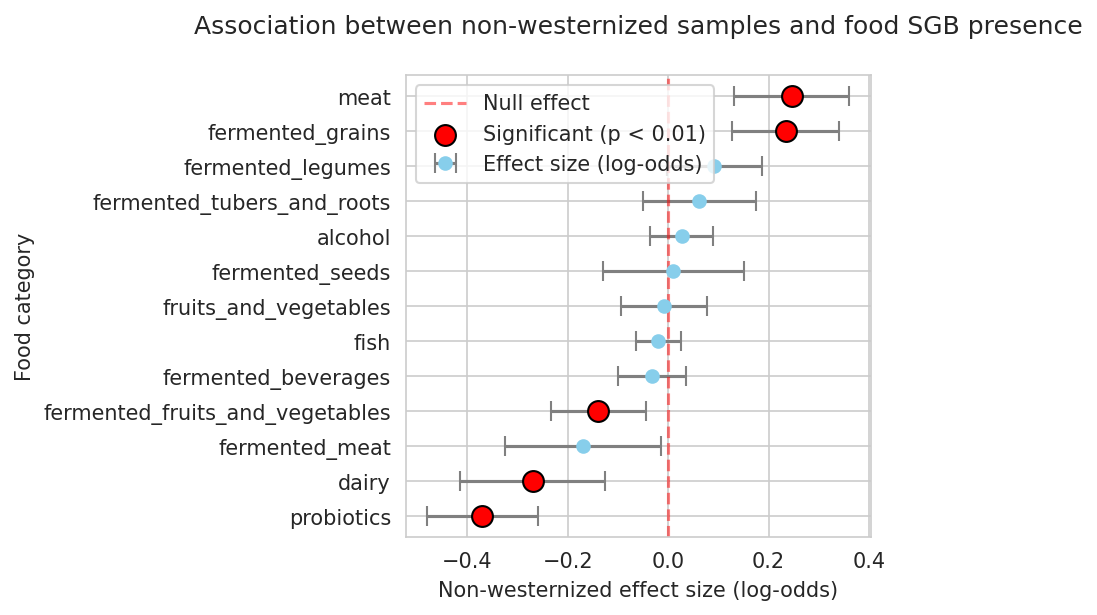

In [781]:


# Sort food categories by effect size for better visualization
df_results = df_results.sort_values("non_westernized[T.yes]_coef")

# Create the plot
plt.figure(figsize=(4,4),dpi=150)
sns.set_style("whitegrid")

# Scatter plot with error bars
plt.errorbar(
    x=df_results["non_westernized[T.yes]_coef"],
    y=df_results["food_category"],
    xerr=[df_results["non_westernized[T.yes]_coef"] - df_results["non_westernized[T.yes]_ci_lower"],
          df_results["non_westernized[T.yes]_ci_upper"] - df_results["non_westernized[T.yes]_coef"]],
    fmt="o",
    color="skyblue",
    ecolor="gray",
    capsize=5,
    label="Effect size (log-odds)"
)

# Add vertical line at zero (no effect)
plt.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="Null effect")

# Add significance markers
for i, row in df_results.iterrows():
    if row["non_westernized[T.yes]_pvalue"] < 0.01:
        plt.scatter(
            row["non_westernized[T.yes]_coef"],
            row["food_category"],
            color="red",
            s=100,
            edgecolor="black",
            zorder=10,
            label="Significant (p < 0.01)" if i == 0 else ""
        )

# Labels and title
plt.xlabel("Non-westernized effect size (log-odds)")
plt.ylabel("Food category")
plt.title("Association between non-westernized samples and food SGB presence", pad=20)
plt.legend(loc="upper left")

# # Add sample size annotations
# for i, row in df_results.iterrows():
#     plt.text(
#         row["non_westernized[T.yes]_coef"] + 0.05,  # Offset to avoid overlap
#         i,
#         f"n={row['n_samples']}",
#         va="center",
#         fontsize=9
#     )

# plt.tight_layout()
plt.savefig("../fig/food_enrichment_remodel.png",format="png",dpi=500, bbox_inches="tight")
plt.show()

In [777]:
total_sgbs_per_food_cat

{'dairy': 1650,
 'fermented_meat': 133,
 'meat': 47,
 'fish': 14,
 'fruits_and_vegetables': 25,
 'fermented_tubers_and_roots': 24,
 'fermented_fruits_and_vegetables': 34,
 'fermented_seeds': 13,
 'fermented_legumes': 16,
 'probiotics': 14,
 'fermented_beverages': 422,
 'fermented_grains': 80,
 'alcohol': 48}

In [705]:
df = food_per_study.copy()
df["gender"] = df.gender.fillna("unknown")

results = []
food_df = df[df.food_category=="dairy"]

# Create binary outcome: has this food SGB (1) or not (0)
food_df['has_food_sgb'] = (food_df['n_food_sgbs'] > 0).astype(int)

# Model formula - adjust confounders as needed
formula = "has_food_sgb ~ non_westernized + age + gender + number_reads + C(study_name)"

# Fit logistic regression with study as fixed effect
try:
    model = smf.logit(
        formula,
        data=food_df
    ).fit(disp=0)  # disp=0 suppresses output
    
    # Store results
    results.append({
        'food_category': food,
        'n_samples': len(food_df),
        'n_positive': food_df['has_food_sgb'].sum(),
        'or_nw': np.exp(model.params['non_westernized']),
        'p_value': model.pvalues['non_westernized'],
        'ci_low': np.exp(model.conf_int().loc['non_westernized', 0]),
        'ci_high': np.exp(model.conf_int().loc['non_westernized', 1])
    })
except Exception as e:
    print(f"Failed for {food}: {str(e)}")
    # continue

/tmp/ipykernel_477782/3181158105.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  food_df['has_food_sgb'] = (food_df['n_food_sgbs'] > 0).astype(int)


Failed for probiotics: 'non_westernized'


/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [706]:
food_df

,non_westernized,study_name,age,gender,sequencing_platform,DNA_extraction_kit,number_reads,n_food_sgbs,food_category,n_total_sgbs,has_food_sgb
O2_UC49_0,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,60584637.0,0,dairy,1650,0
O2_UC49_2,no,NielsenHB_2014,22.0,female,IlluminaHiSeq,unknown,56508214.0,2,dairy,1650,1
O2_UC50_0,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,65105855.0,1,dairy,1650,1
O2_UC50_2,no,NielsenHB_2014,24.0,male,IlluminaHiSeq,unknown,53260679.0,1,dairy,1650,1
O2_UC51_0,no,NielsenHB_2014,32.0,female,IlluminaHiSeq,unknown,57486896.0,2,dairy,1650,1
...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,yes,CM_tanzania,20.0,male,IlluminaHiSeq,Qiagen,38426298.0,0,dairy,1650,0
C16-20645-TZ,yes,CM_tanzania,34.0,female,IlluminaHiSeq,Qiagen,66130906.0,0,dairy,1650,0
C16-20646-TZ,yes,CM_tanzania,40.0,male,IlluminaHiSeq,Qiagen,66850184.0,0,dairy,1650,0
C16-20647-TZ,yes,CM_tanzania,18.0,female,IlluminaHiSeq,Qiagen,62136875.0,0,dairy,1650,0


In [698]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

food_cat = "dairy" # example

df_cat = df[df['food_category'] == food_cat].copy()

# Prepare categorical variables as categorical dtype
df_cat['gender'] = df_cat['gender'].astype('category')
df_cat['sequencing_platform'] = df_cat['sequencing_platform'].astype('category')
df_cat['DNA_extraction_kit'] = df_cat['DNA_extraction_kit'].astype('category')
df_cat['study_name'] = df_cat['study_name'].astype('category')
df_cat['non_westernized'] = df_cat['non_westernized'].astype('category')

# Build model formula
formula = 'n_food_sgbs ~ non_westernized + age + gender + sequencing_platform + DNA_extraction_kit + number_reads + study_name'

# Fit binomial model with total trials = n_total_sgbs
# Use GLM with Binomial family and weights = n_total_sgbs
model = smf.glm(formula=formula,
                data=df_cat,
                family=sm.families.Binomial(),
                freq_weights=df_cat['n_total_sgbs'])

res = model.fit()
results[food_cat] = res
print(f"Results for {food_cat}:")
print(res.summary())
print('\n')


/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


Results for dairy:
                 Generalized Linear Model Regression Results                  
Dep. Variable:            n_food_sgbs   No. Observations:                 6791
Model:                            GLM   Df Residuals:                 11205089
Model Family:                Binomial   Df Model:                           60
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Fri, 11 Jul 2025   Deviance:                   6.5175e+08
Time:                        14:16:04   Pearson chi2:                 5.96e+22
No. Iterations:                    43   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/home/sebastiaan.valkiers/miniconda3/envs/westnonwest/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


56